<!-- colab-badge -->
[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bmnogueira-ufms/IA-2026-02/blob/main/Aulas%20Pr%C3%A1ticas/aula01-introducao-am/aula01-introducao-am.ipynb)

# Aula Prática 01 - Introdução ao Aprendizado de Máquina

**Inteligência Artificial - Graduação**
Prof. Bruno Nogueira - FACOM/UFMS - 2026/2

---

## Do que trata esta aula

Esta é a nossa primeira aula prática de Aprendizado de Máquina (AM). O objetivo é
**colocar a mão na massa em tudo que vimos na teoria até aqui**, usando Python.
Ao final, você terá construído, avaliado e comparado modelos reais - e, mais
importante, terá entendido *por que* cada passo existe.

### Roteiro

| # | Tema | Conceito da teoria |
|---|------|--------------------|
| 1 | A definição de aprendizado | Mitchell: tarefa **T**, desempenho **P**, experiência **E** |
| 2 | Aprendizado indutivo | encontrar $h \approx f$, Navalha de Ockham, *overfitting* |
| 3 | Anatomia de um conjunto de dados | atributos $X$ e classe $y$ |
| 4 | Hierarquia do aprendizado | supervisionado / não supervisionado / semissupervisionado |
| 5 | Separabilidade linear | fronteiras de decisão |
| 6 | Árvores de decisão | hipóteses $H_1 \ldots H_4$, qual é a melhor? |
| 7 | Estudo de caso real | diagnóstico de doença cardíaca |
| 8 | Avaliação | matriz de confusão, acurácia, precisão, revocação, F1 |
| 9 | Escolha de complexidade | curva treino × teste |
| 10 | Validação | *holdout* e *k-fold cross validation* |
| 11 | Mais de duas classes | *micro* e *macro averaging* |

### ⚠️ Uma observação importante sobre o escopo

Ao longo da aula vamos **usar** alguns algoritmos de classificação - árvore de decisão,
KNN, regressão logística, K-Means. Trate-os, por enquanto, como **caixas-pretas**:
você não precisa saber como eles funcionam por dentro, e nós ainda não estudamos isso.

O que interessa hoje é tudo o que está **em volta** do algoritmo, e que vale para
qualquer um deles: como formular o problema, como preparar os dados, como separar
treino e teste, como medir desempenho e como não se enganar com os próprios resultados.
Essa parte é a que menos muda quando o algoritmo muda - e é a que mais se erra na
prática.

> O funcionamento interno de cada modelo começa na próxima aula.

### Como usar este notebook

Execute as células **na ordem**, de cima para baixo (`Shift + Enter`).
As células marcadas com 🔎 **PARE E PENSE** são perguntas para você responder
*antes* de rodar a célula seguinte. Não pule - é aí que o aprendizado acontece
(o seu, não o da máquina).

Todo o código já vem escrito, inclusive o dos exercícios: em nenhum momento você
precisará implementar um classificador.

---
## 0. Preparando o ambiente

Usaremos as bibliotecas apresentadas na aula teórica:

- **NumPy** - computação numérica com vetores e matrizes
- **pandas** - manipulação de tabelas de dados (`DataFrame`)
- **Matplotlib** - gráficos
- **scikit-learn** - algoritmos de aprendizado de máquina

Se alguma não estiver instalada, rode no terminal:

```bash
pip install numpy pandas matplotlib scikit-learn
```

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

warnings.filterwarnings("ignore")

# Semente aleatória: garante que TODOS na sala obtenham os mesmos números.
# Em AM isso se chama reprodutibilidade - sem isso, não há experimento científico.
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Ajustes de exibição e de gráficos (puramente estéticos)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta segura para daltônicos, usada de forma consistente em todo o notebook
CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

print(f"NumPy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print("\nAmbiente pronto. Vamos aprender a fazer máquinas aprenderem.")

NumPy       2.5.2
pandas      3.0.5
scikit-learn 1.9.0

Ambiente pronto. Vamos aprender a fazer máquinas aprenderem.


---
## 1. Afinal, o que significa "aprender"?

A definição clássica é de **Tom Mitchell (1997)**:

> *"Um programa de computador é dito **aprender** a partir de uma experiência **E**
> com respeito a uma classe de tarefas **T** e medida de desempenho **P**, se seu
> desempenho em tarefas de **T**, medido por **P**, melhora com a experiência **E**."*

Repare no que essa definição exige: **um problema de AM só está bem definido quando
conseguimos nomear as três coisas**. Se você não consegue dizer qual é o P, você não
consegue saber se o seu programa aprendeu ou não.

Vamos formalizar alguns problemas.

In [2]:
def descrever_problema(nome, tarefa, desempenho, experiencia):
    """Imprime um problema de AM no formato (T, P, E) de Mitchell."""
    print(f"\n{'=' * 72}\n {nome.upper()}\n{'=' * 72}")
    print(f"  T (tarefa)      : {tarefa}")
    print(f"  P (desempenho)  : {desempenho}")
    print(f"  E (experiência) : {experiencia}")


descrever_problema(
    "Aprender a jogar xadrez",
    tarefa="jogar partidas de xadrez",
    desempenho="% de vitórias contra oponentes",
    experiencia="jogar milhares de partidas contra si mesmo",
)

descrever_problema(
    "Filtro de spam",
    tarefa="classificar um e-mail como spam ou legítimo",
    desempenho="% de e-mails classificados corretamente (e, sobretudo, "
    "quantos e-mails legítimos foram parar no lixo)",
    experiencia="base de e-mails previamente rotulados por usuários",
)

descrever_problema(
    "Diagnóstico de doença cardíaca",  # <- o nosso estudo de caso de hoje!
    tarefa="prever se um paciente tem doença arterial coronariana",
    desempenho="% de pacientes doentes corretamente identificados",
    experiencia="303 prontuários de pacientes já diagnosticados (Cleveland Clinic)",
)


 APRENDER A JOGAR XADREZ
  T (tarefa)      : jogar partidas de xadrez
  P (desempenho)  : % de vitórias contra oponentes
  E (experiência) : jogar milhares de partidas contra si mesmo

 FILTRO DE SPAM
  T (tarefa)      : classificar um e-mail como spam ou legítimo
  P (desempenho)  : % de e-mails classificados corretamente (e, sobretudo, quantos e-mails legítimos foram parar no lixo)
  E (experiência) : base de e-mails previamente rotulados por usuários

 DIAGNÓSTICO DE DOENÇA CARDÍACA
  T (tarefa)      : prever se um paciente tem doença arterial coronariana
  P (desempenho)  : % de pacientes doentes corretamente identificados
  E (experiência) : 303 prontuários de pacientes já diagnosticados (Cleveland Clinic)


🔎 **PARE E PENSE**

Escolha um problema do seu dia a dia (recomendar filmes, detectar fraude no cartão,
prever a nota de um aluno, reconhecer a sua letra...) e escreva o **T**, o **P** e o
**E** dele. Você vai perceber que o **P** é quase sempre a parte mais difícil - e a
mais importante.

> **Por que AM, e não simplesmente programar a regra?**
> Porque há tarefas que nem nós sabemos explicar: você sabe reconhecer o rosto da sua
> mãe, mas não consegue escrever o `if` que faz isso. E há tarefas em que o volume de
> conhecimento é grande demais para ser codificado à mão (diagnóstico médico), ou em
> que o ambiente muda com o tempo e o sistema precisa se adaptar sozinho.

---
## 2. Aprendizado indutivo: procurando $h \approx f$

Existe uma função **alvo** $f$ - desconhecida - que gera os dados do mundo real.
Nós só observamos **exemplos**, isto é, pares $(x, f(x))$.

A tarefa do aprendizado indutivo é encontrar uma **hipótese** $h$ tal que
$h \approx f$, a partir de um conjunto de treinamento. Isso é **indução**:
vamos do particular (alguns exemplos) para o geral (uma regra).

| Argumento **dedutivo** | Argumento **indutivo** |
|---|---|
| Se as premissas são verdadeiras, a conclusão **é** verdadeira | Se as premissas são verdadeiras, a conclusão é **provavelmente** verdadeira |
| A conclusão não acrescenta informação nova | A conclusão contém informação que **não estava** nas premissas |

É exatamente esse "provavelmente" que torna o AM interessante - e perigoso.
Vamos ver o perigo na prática.

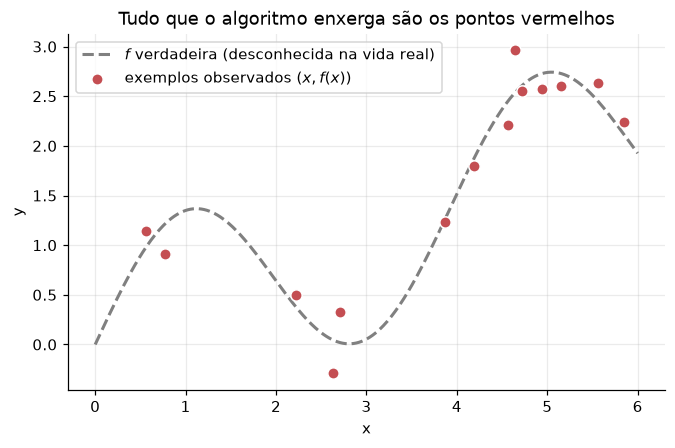

In [3]:
# --- O experimento do ajuste de curvas (os slides da teoria, agora em código) ---

# Esta é a função ALVO f. No mundo real, ela é DESCONHECIDA: só a conhecemos aqui
# porque nós mesmos a inventamos, para poder comparar h com f no final.
def f_verdadeira(x):
    return np.sin(1.6 * x) + 0.35 * x


# Observamos apenas alguns exemplos, e ainda por cima com RUÍDO de medição
n_exemplos = 14
x_treino = np.sort(rng.uniform(0, 6, n_exemplos))
y_treino = f_verdadeira(x_treino) + rng.normal(0, 0.35, n_exemplos)

x_denso = np.linspace(0, 6, 400)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(x_denso, f_verdadeira(x_denso), color="gray", lw=2, ls="--",
        label="$f$ verdadeira (desconhecida na vida real)")
ax.scatter(x_treino, y_treino, color=CORES[3], s=55, zorder=5,
           edgecolor="white", label="exemplos observados $(x, f(x))$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Tudo que o algoritmo enxerga são os pontos vermelhos")
ax.legend()
plt.show()

Agora vamos ajustar hipóteses $h$ de diferentes **complexidades** (polinômios de
grau 1, 3 e 15) a esses mesmos 14 pontos.

🔎 **PARE E PENSE**: antes de rodar, qual das três você acha que vai *acertar melhor
os 14 pontos*? E qual vai *representar melhor a função verdadeira*? São a mesma?

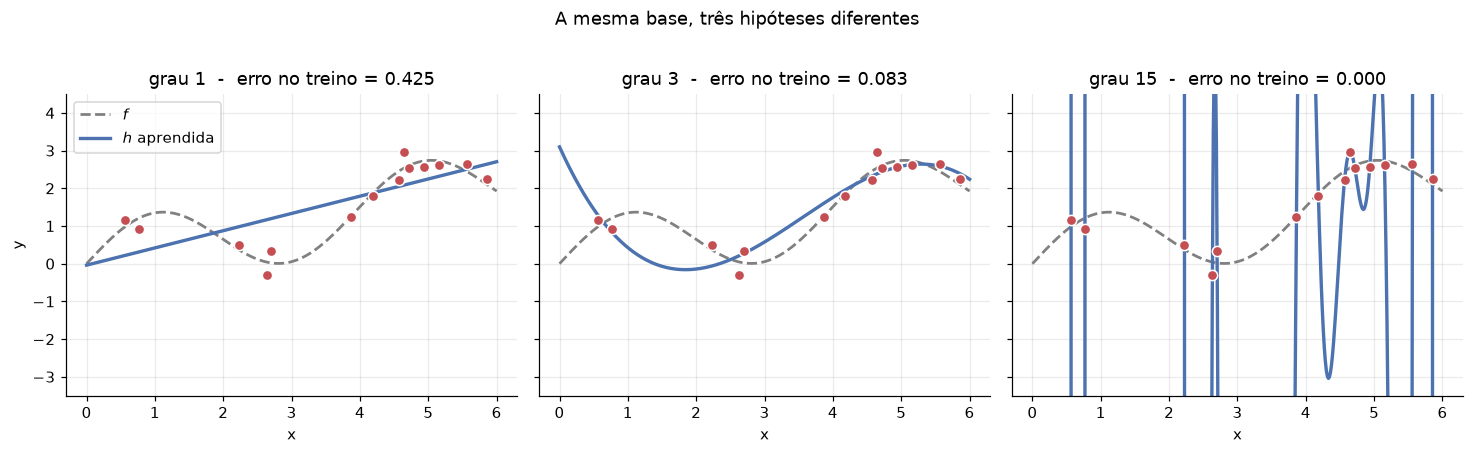

In [4]:
graus = [1, 3, 15]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True)

for ax, grau in zip(axes, graus):
    # np.polyfit encontra o polinômio de grau `grau` que melhor se ajusta aos pontos.
    # Esse polinômio é a nossa hipótese h.
    coefs = np.polyfit(x_treino, y_treino, grau)
    h = np.poly1d(coefs)

    erro_treino = np.mean((h(x_treino) - y_treino) ** 2)

    ax.plot(x_denso, f_verdadeira(x_denso), color="gray", lw=1.8, ls="--", label="$f$")
    ax.plot(x_denso, h(x_denso), color=CORES[0], lw=2.2, label="$h$ aprendida")
    ax.scatter(x_treino, y_treino, color=CORES[3], s=45, zorder=5, edgecolor="white")
    ax.set_ylim(-3.5, 4.5)
    ax.set_title(f"grau {grau}  -  erro no treino = {erro_treino:.3f}")
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
axes[0].legend(loc="upper left")
fig.suptitle("A mesma base, três hipóteses diferentes", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Repare no que aconteceu:

- **Grau 1** (uma reta): erro de treino alto. A hipótese é simples demais para
  capturar o formato de $f$. Chamamos isso de ***underfitting*** (sub-ajuste).
- **Grau 3**: erro de treino moderado, e a curva acompanha bem a função verdadeira.
- **Grau 15**: erro de treino quase **zero** - ela passa praticamente em cima de todos
  os pontos! E, ainda assim, é a **pior** representação de $f$: entre os pontos ela
  dispara para cima e para baixo de forma absurda.

> O grau 15 é *consistente* (ajusta-se a todos os exemplos), mas **decorou** o
> conjunto de treinamento, ruído e tudo. Isso é ***overfitting*** (sobreajuste).

**Navalha de Ockham**: entre hipóteses que explicam igualmente bem os dados,
prefira a mais simples.

E aqui está a lição prática mais importante desta aula:

> ### ⚠️ O erro no conjunto de treinamento MENTE.
> Ele sempre melhora quando aumentamos a complexidade do modelo. Para saber se
> aprendemos de verdade, precisamos medir o desempenho em **dados que o modelo nunca
> viu** - o **conjunto de teste**. E, obrigatoriamente:
> $$D_{teste} \cap D_{treino} = \varnothing$$

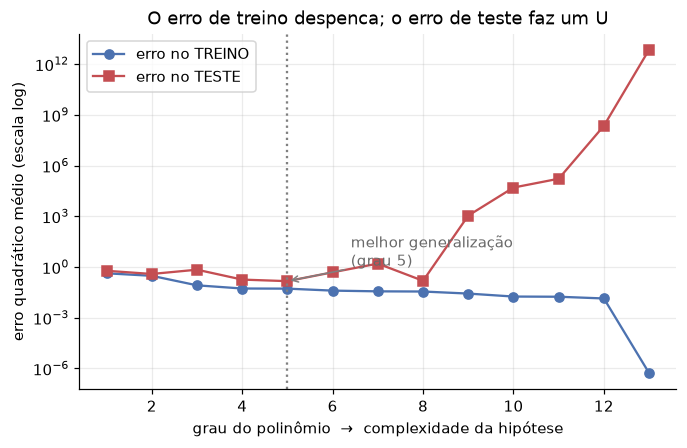

O modelo que melhor GENERALIZA é o de grau 5, e não o de maior complexidade.


In [5]:
# Vamos provar isso: geramos um conjunto de TESTE (novos pontos da mesma f)
# e medimos o erro dos polinômios de grau 1 até 15 nos dois conjuntos.
x_teste = np.sort(rng.uniform(0, 6, 60))
y_teste = f_verdadeira(x_teste) + rng.normal(0, 0.35, 60)

graus_testados = range(1, 14)
erros_treino, erros_teste = [], []

for grau in graus_testados:
    h = np.poly1d(np.polyfit(x_treino, y_treino, grau))
    erros_treino.append(np.mean((h(x_treino) - y_treino) ** 2))
    erros_teste.append(np.mean((h(x_teste) - y_teste) ** 2))

melhor_grau = list(graus_testados)[int(np.argmin(erros_teste))]

fig, ax = plt.subplots()
ax.plot(graus_testados, erros_treino, "o-", color=CORES[0], label="erro no TREINO")
ax.plot(graus_testados, erros_teste, "s-", color=CORES[3], label="erro no TESTE")
ax.axvline(melhor_grau, color="gray", ls=":", lw=1.5)
ax.annotate(f"melhor generalização\n(grau {melhor_grau})",
            xy=(melhor_grau, min(erros_teste)), xytext=(melhor_grau + 1.4, 1.2),
            arrowprops=dict(arrowstyle="->", color="gray"), color="dimgray")
ax.set_yscale("log")
ax.set_xlabel("grau do polinômio  →  complexidade da hipótese")
ax.set_ylabel("erro quadrático médio (escala log)")
ax.set_title("O erro de treino despenca; o erro de teste faz um U")
ax.legend()
plt.show()

print(f"O modelo que melhor GENERALIZA é o de grau {melhor_grau}, "
      f"e não o de maior complexidade.")

Essa curva em **U** é uma das imagens mais importantes de todo o Aprendizado de
Máquina. Guarde-a: vamos reencontrá-la na Seção 9, com um classificador de verdade.

> **Nota**: este exemplo foi de **regressão** (a saída é um número contínuo).
> O sobreajuste, como você acabou de ver, não é um problema exclusivo da
> classificação - ele aparece em qualquer modelo indutivo.

---
## 3. Anatomia de um conjunto de dados

Em aprendizado **supervisionado**, a experiência $E$ é um conjunto de pares $(x, y)$
fornecido por um "professor" (um especialista que rotulou os dados):

- $x$ = **variáveis independentes**, também chamadas de *atributos* ou *features*
- $y$ = **variável dependente**, também chamada de *classe*, *rótulo* ou *alvo*

Vamos usar a base **Iris** (Fisher, 1936), o "Olá, Mundo!" do AM: medidas de sépalas
e pétalas de 150 flores de três espécies.

In [6]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()

# Traduzindo os nomes para deixar a leitura mais clara
df_iris.columns = ["sepala_comp", "sepala_larg", "petala_comp", "petala_larg", "classe"]
df_iris["especie"] = df_iris["classe"].map(dict(enumerate(iris.target_names)))

print(f"Formato da tabela: {df_iris.shape[0]} exemplos × {df_iris.shape[1] - 2} atributos")
print("\nDistribuição das classes:")
print(df_iris["especie"].value_counts().to_string())
df_iris.head()

Formato da tabela: 150 exemplos × 4 atributos

Distribuição das classes:
especie
setosa        50
versicolor    50
virginica     50


,sepala_comp,sepala_larg,petala_comp,petala_larg,classe,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
# Separando explicitamente X (atributos) de y (classe) - este é O gesto fundamental
X_iris = df_iris[["sepala_comp", "sepala_larg", "petala_comp", "petala_larg"]]
y_iris = df_iris["especie"]

print("X - variáveis independentes (atributos)")
print(X_iris.head(3).to_string(index=False))
print("\ny - variável dependente (classe)")
print(y_iris.head(3).to_string(index=False))

print(f"\nX tem formato {X_iris.shape}  →  (n_exemplos, n_atributos)")
print(f"y tem formato {y_iris.shape}    →  (n_exemplos,)")

X - variáveis independentes (atributos)
 sepala_comp  sepala_larg  petala_comp  petala_larg
         5.1          3.5          1.4          0.2
         4.9          3.0          1.4          0.2
         4.7          3.2          1.3          0.2

y - variável dependente (classe)
setosa
setosa
setosa

X tem formato (150, 4)  →  (n_exemplos, n_atributos)
y tem formato (150,)    →  (n_exemplos,)


**Tipos de atributos** - a escolha do algoritmo e do pré-processamento depende disso:

| Tipo | Descrição | Exemplo |
|---|---|---|
| **Numérico contínuo** | valores reais, com ordem e distância | `petala_comp` = 4.7 cm |
| **Numérico discreto** | contagens inteiras | nº de vasos obstruídos = 2 |
| **Categórico nominal** | categorias **sem** ordem | tipo de dor no peito |
| **Categórico ordinal** | categorias **com** ordem | escolaridade: fundamental < médio < superior |
| **Binário** | dois valores | fumante: sim/não |

Todos os quatro atributos da Iris são numéricos contínuos. Na Seção 7 vamos trabalhar
com uma base que mistura tudo - como acontece na vida real.

---
## 4. A hierarquia do aprendizado

```
                       Aprendizado Indutivo
                                |
        +-----------------------+-----------------------+
        |                       |                       |
  Supervisionado        Não Supervisionado      Semissupervisionado
  classes conhecidas    classes desconhecidas   classes parcialmente conhecidas
```

A melhor forma de sentir a diferença é aplicar os três paradigmas **à mesma base**.

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.semi_supervised import LabelSpreading

# ------------------------------------------------------------------
# 4.1  SUPERVISIONADO - temos um "professor": todos os rótulos
# ------------------------------------------------------------------
Xtr, Xte, ytr, yte = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=RANDOM_STATE, stratify=y_iris
)
knn = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
acc_sup = accuracy_score(yte, knn.predict(Xte))

print("① SUPERVISIONADO (KNN, 100% dos rótulos de treino)")
print(f"   acurácia no teste: {acc_sup:.1%}")

① SUPERVISIONADO (KNN, 100% dos rótulos de treino)
   acurácia no teste: 97.8%


In [9]:
# ------------------------------------------------------------------
# 4.2  NÃO SUPERVISIONADO - escondemos TODOS os rótulos.
#      O algoritmo só pode olhar para a geometria dos dados.
# ------------------------------------------------------------------
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_iris)
grupos = kmeans.labels_

print("② NÃO SUPERVISIONADO (K-Means, ZERO rótulos)")
print("\n   Grupos descobertos × espécies reais:")
print(pd.crosstab(grupos, y_iris, rownames=["grupo"], colnames=["espécie real"]))

# O Índice de Rand Ajustado mede a concordância entre dois agrupamentos
# (1.0 = idênticos, 0.0 = concordância ao acaso).
print(f"\n   Índice de Rand Ajustado: {adjusted_rand_score(y_iris, grupos):.3f}")

② NÃO SUPERVISIONADO (K-Means, ZERO rótulos)

   Grupos descobertos × espécies reais:
espécie real  setosa  versicolor  virginica
grupo                                      
0                  0          48         14
1                 50           0          0
2                  0           2         36

   Índice de Rand Ajustado: 0.730


🔎 **PARE E PENSE**: repare que o K-Means **não sabe** que existem espécies chamadas
*setosa*, *versicolor* e *virginica*. Ele apenas encontrou três aglomerados de pontos.
Um deles é isolado e foi recuperado perfeitamente; os outros dois se confundem.

Repare também que os *números* dos grupos não correspondem aos números das classes -
o grupo 0 pode ser a *virginica*. Em agrupamento, **os rótulos são arbitrários**;
só a partição importa. Por isso usamos o Índice de Rand Ajustado, e não acurácia.

In [10]:
# ------------------------------------------------------------------
# 4.3  SEMISSUPERVISIONADO - só 10% dos exemplos têm rótulo.
#      É a situação MAIS COMUM na prática: rotular custa caro
#      (um médico, um advogado ou um biólogo precisa parar e olhar cada caso).
# ------------------------------------------------------------------
y_num = df_iris["classe"].to_numpy()
y_parcial = y_num.copy()

# Escondemos 90% dos rótulos: em scikit-learn, -1 significa "não rotulado"
n_rotulados = 15  # 10% de 150
indices = rng.permutation(len(y_num))
y_parcial[indices[n_rotulados:]] = -1
mask_rotulado = y_parcial != -1

# (a) Só com os 15 exemplos rotulados, de forma supervisionada
knn_pouco = KNeighborsClassifier(n_neighbors=3).fit(X_iris[mask_rotulado], y_num[mask_rotulado])
acc_pouco = accuracy_score(y_num[~mask_rotulado], knn_pouco.predict(X_iris[~mask_rotulado]))

# (b) Usando os 15 rotulados MAIS a estrutura geométrica dos 135 não rotulados
ls = LabelSpreading(kernel="knn", n_neighbors=7).fit(X_iris, y_parcial)
acc_semi = accuracy_score(y_num[~mask_rotulado], ls.transduction_[~mask_rotulado])

print("③ SEMISSUPERVISIONADO (apenas 15 de 150 exemplos rotulados)")
print(f"   (a) supervisionado usando só os 15 rotulados : {acc_pouco:.1%}")
print(f"   (b) semissupervisionado (15 rótulos + 135 sem): {acc_semi:.1%}")
print(f"\n   Ganho ao aproveitar os dados NÃO rotulados: {acc_semi - acc_pouco:+.1%}")

③ SEMISSUPERVISIONADO (apenas 15 de 150 exemplos rotulados)
   (a) supervisionado usando só os 15 rotulados : 86.7%
   (b) semissupervisionado (15 rótulos + 135 sem): 94.8%

   Ganho ao aproveitar os dados NÃO rotulados: +8.1%


### Quadro-resumo: tarefas × paradigmas

| Tarefa | Tipo da saída | Paradigma |
|---|---|---|
| **Regressão** | contínua (um número) | supervisionado (e semissupervisionado) |
| **Classificação** | discreta (uma classe) | supervisionado (e semissupervisionado) |
| **Agrupamento** *(clustering)* | grupos descobertos | não supervisionado |
| **Regras de associação** | padrões do tipo "se A então B" | não supervisionado |

> A escolha do algoritmo **depende da tarefa**. Não existe "o melhor algoritmo de AM";
> existe o algoritmo adequado a um problema, a um tipo de dado e a uma medida $P$.

---
## 5. Classificação: a intuição geométrica

> **Classificação** é a tarefa de designar objetos a uma classe pertencente a um
> conjunto de classes **predefinidas**. Formalmente: aprender uma função $f$ que
> mapeia um vetor de atributos $x$ a um rótulo $y$.

Em quase todo problema de classificação existe uma **interpretação geométrica**: cada
exemplo é um ponto num espaço de atributos, e classificar é dividir esse espaço em
regiões. Vamos ver com duas dimensões da Iris.

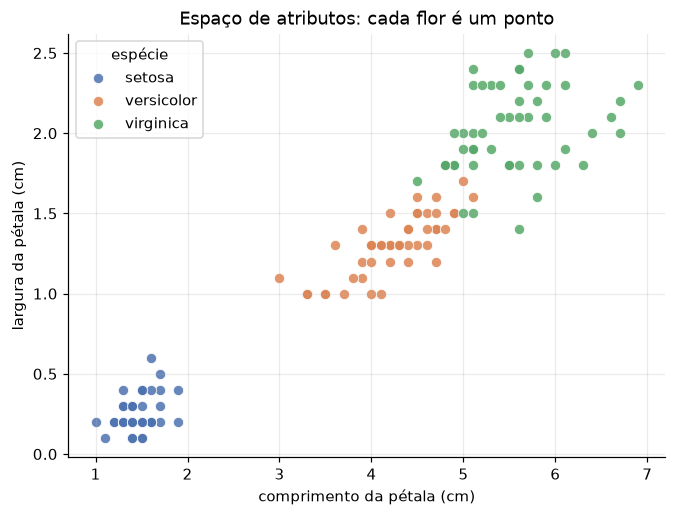

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for cor, especie in zip(CORES, iris.target_names):
    sub = df_iris[df_iris["especie"] == especie]
    ax.scatter(sub["petala_comp"], sub["petala_larg"], s=45, alpha=0.85,
               color=cor, edgecolor="white", linewidth=0.6, label=especie)

ax.set_xlabel("comprimento da pétala (cm)")
ax.set_ylabel("largura da pétala (cm)")
ax.set_title("Espaço de atributos: cada flor é um ponto")
ax.legend(title="espécie")
plt.show()

🔎 **PARE E PENSE**: você consegue traçar **uma única reta** que separe perfeitamente
a *setosa* das demais? E uma reta que separe *versicolor* de *virginica*?

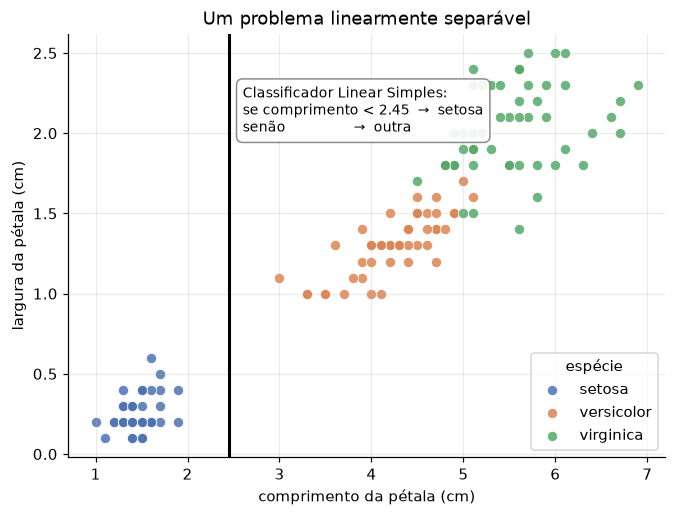

Acurácia da regra escrita à mão: 100.0%


In [12]:
# A setosa é LINEARMENTE SEPARÁVEL das demais: uma reta basta.
limiar = 2.45  # comprimento de pétala

fig, ax = plt.subplots(figsize=(7, 5))
for cor, especie in zip(CORES, iris.target_names):
    sub = df_iris[df_iris["especie"] == especie]
    ax.scatter(sub["petala_comp"], sub["petala_larg"], s=45, alpha=0.85,
               color=cor, edgecolor="white", linewidth=0.6, label=especie)
ax.axvline(limiar, color="black", lw=2)
ax.text(limiar + 0.15, 2.3, "Classificador Linear Simples:\n"
        "se comprimento < 2.45  →  setosa\nsenão                 →  outra",
        fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="gray", alpha=0.9))
ax.set_xlabel("comprimento da pétala (cm)")
ax.set_ylabel("largura da pétala (cm)")
ax.set_title("Um problema linearmente separável")
ax.legend(title="espécie", loc="lower right")
plt.show()

# Avaliando essa regra escrita à mão (sem nenhum algoritmo!)
predicao_manual = np.where(df_iris["petala_comp"] < limiar, "setosa", "outra")
real_binario = np.where(df_iris["especie"] == "setosa", "setosa", "outra")
print(f"Acurácia da regra escrita à mão: {accuracy_score(real_binario, predicao_manual):.1%}")

Perfeito - mas esse é o caso fácil. **Quase nenhum problema real é linearmente
separável.** *Versicolor* e *virginica* se sobrepõem, e nenhuma reta as separa sem
erro. É aí que precisamos de modelos mais expressivos.

Vamos comparar três modelos diferentes olhando para as suas **fronteiras de decisão** - as linhas que dividem o espaço de atributos em regiões de classe.

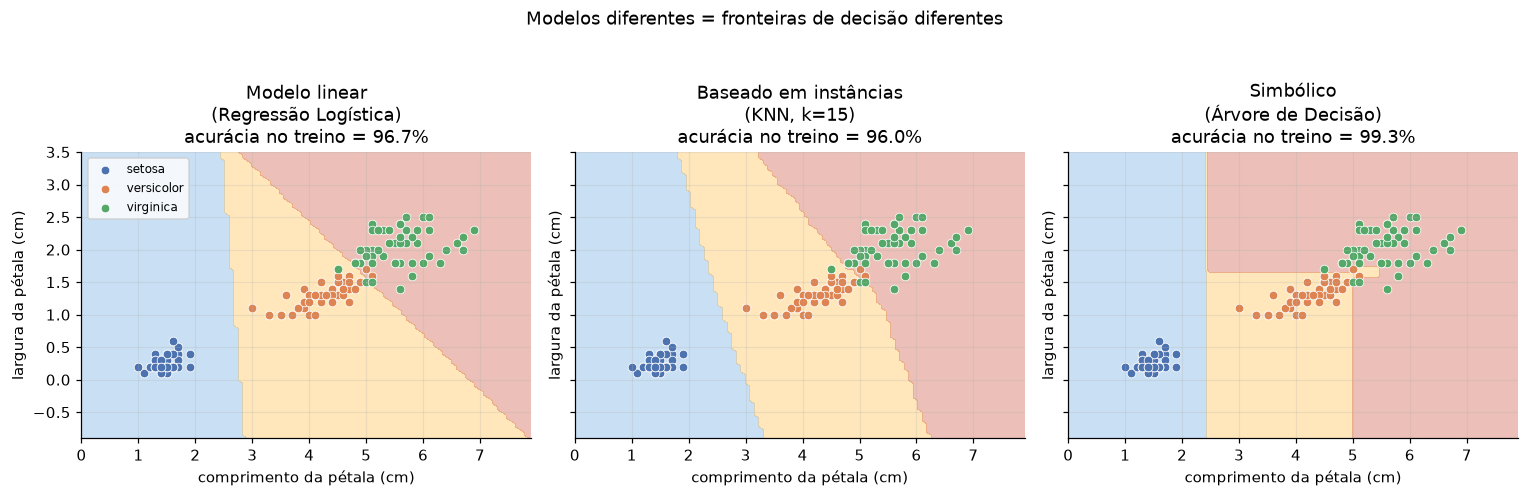

In [13]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

X2 = df_iris[["petala_comp", "petala_larg"]].to_numpy()
y2 = df_iris["classe"].to_numpy()

modelos = {
    "Modelo linear\n(Regressão Logística)": LogisticRegression(max_iter=1000),
    "Baseado em instâncias\n(KNN, k=15)": KNeighborsClassifier(n_neighbors=15),
    "Simbólico\n(Árvore de Decisão)": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
for ax, (nome, modelo) in zip(axes, modelos.items()):
    modelo.fit(X2, y2)
    DecisionBoundaryDisplay.from_estimator(
        modelo, X2, ax=ax, alpha=0.28, cmap="Pastel1", response_method="predict",
        xlabel="comprimento da pétala (cm)", ylabel="largura da pétala (cm)",
    )
    for k, (cor, especie) in enumerate(zip(CORES, iris.target_names)):
        m = y2 == k
        ax.scatter(X2[m, 0], X2[m, 1], s=32, color=cor, edgecolor="white",
                   linewidth=0.5, label=especie)
    ax.set_title(f"{nome}\nacurácia no treino = {modelo.score(X2, y2):.1%}")

axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Modelos diferentes = fronteiras de decisão diferentes", y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

Três **paradigmas de representação** distintos, todos vistos na teoria:

- **Modelos matemáticos** (regressão logística, redes neurais, SVM) → fronteiras suaves
- **Modelos "lazy"/baseados em instâncias** (KNN) → fronteiras irregulares, ditadas
  pelos vizinhos mais próximos
- **Modelos simbólicos** (árvores de decisão, regras lógicas) → fronteiras sempre
  paralelas aos eixos, porque cada decisão é um teste do tipo `atributo < valor`

🔎 **PARE E PENSE**: a árvore acertou **100%** no treino. Depois do que vimos na
Seção 2, isso deveria te deixar entusiasmado ou desconfiado?

---
## 6. Árvores de decisão e a pergunta "qual é a melhor hipótese?"

Vamos reproduzir o exemplo de **crédito bancário** da aula teórica: classificar
clientes como bons ou maus pagadores a partir de **idade** e **renda**.

A árvore de decisão constrói a hipótese fazendo **cortes sucessivos** no espaço:
`Idade < 25?`, `Renda > 1k?`, e assim por diante - exatamente o desenho dos slides.

In [14]:
# Gerando uma base sintética com a mesma "cara" do exemplo da aula teórica.
# (Sintética porque queremos controlar exatamente o formato do problema.)
n = 400
idade = rng.uniform(18, 70, n)
renda = rng.uniform(500, 9000, n)

# A regra "verdadeira" oculta que gera as classes:
#   jovens demais e renda baixa -> ruim ;  meia-idade com boa renda -> bom
bom = ((idade >= 25) & (idade <= 45) & (renda > 5000)) | ((idade > 45) & (renda > 6500))
ruido = rng.random(n) < 0.07          # 7% de rótulos ruidosos, como na vida real
classe = np.where(bom ^ ruido, "Bom", "Ruim")

credito = pd.DataFrame({"idade": idade, "renda": renda, "classe": classe})
Xc = credito[["idade", "renda"]].to_numpy()
yc = (credito["classe"] == "Bom").astype(int).to_numpy()

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, random_state=RANDOM_STATE, stratify=yc
)
print(credito["classe"].value_counts().to_string())
credito.head()

classe
Ruim    267
Bom     133


,idade,renda,classe
0,60.461576,7753.429705,Bom
1,23.474460,3041.021035,Ruim
2,21.461061,5517.722133,Ruim
3,48.910551,3873.990576,Ruim
4,25.601009,2836.012931,Ruim


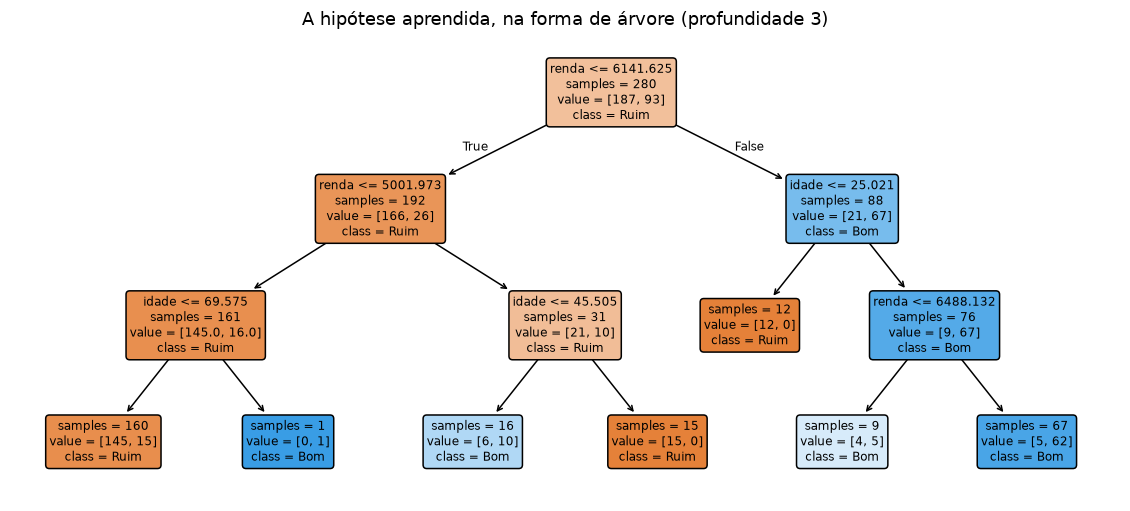

In [15]:
from sklearn.tree import plot_tree

arvore = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)

fig, ax = plt.subplots(figsize=(13, 5.5))
plot_tree(arvore, feature_names=["idade", "renda"], class_names=["Ruim", "Bom"],
          filled=True, rounded=True, fontsize=8, impurity=False, ax=ax)
ax.set_title("A hipótese aprendida, na forma de árvore (profundidade 3)")
plt.show()

Leia a árvore de cima para baixo: cada nó é uma **pergunta sobre um atributo**, cada
folha é uma **decisão**. Isso é o que chamamos de modelo **simbólico** - ele pode ser
lido, auditado e explicado para um gerente de banco (ou para um juiz).

Agora a pergunta central da aula teórica: existem **muitas** hipóteses possíveis para
a mesma base ($H_1$, $H_2$, $H_3$, $H_4$ dos slides). **Qual delas é a melhor?**

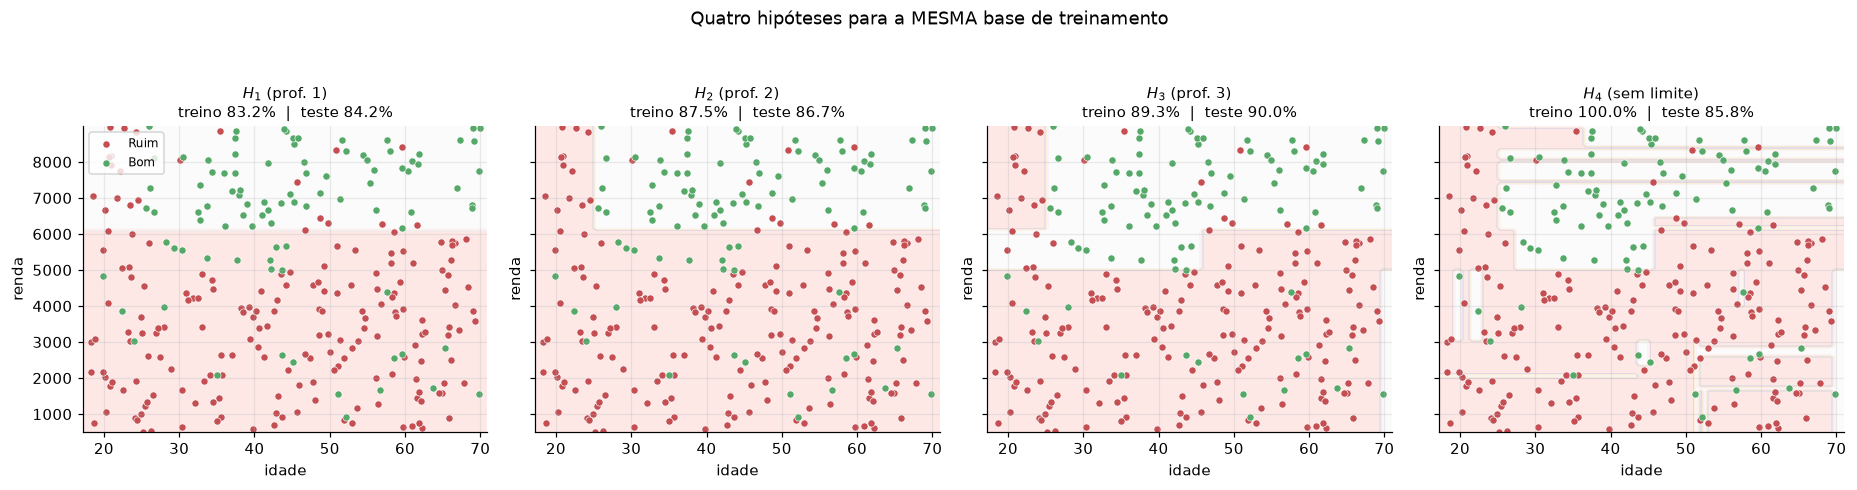

,hipótese,profundidade,acurácia treino,acurácia teste
0,$H_1$ (prof. 1),1,0.832143,0.841667
1,$H_2$ (prof. 2),2,0.875000,0.866667
2,$H_3$ (prof. 3),3,0.892857,0.900000
3,$H_4$ (sem limite),15,1.000000,0.858333


In [16]:
profundidades = [1, 2, 3, None]
nomes_h = ["$H_1$ (prof. 1)", "$H_2$ (prof. 2)", "$H_3$ (prof. 3)", "$H_4$ (sem limite)"]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)
resultados_h = []

for ax, prof, nome in zip(axes, profundidades, nomes_h):
    modelo = DecisionTreeClassifier(max_depth=prof, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    acc_tr = modelo.score(Xc_tr, yc_tr)
    acc_te = modelo.score(Xc_te, yc_te)
    resultados_h.append((nome, modelo.get_depth(), acc_tr, acc_te))

    DecisionBoundaryDisplay.from_estimator(
        modelo, Xc_tr, ax=ax, alpha=0.3, cmap="Pastel1", response_method="predict",
        xlabel="idade", ylabel="renda",
    )
    ax.scatter(Xc_tr[yc_tr == 0, 0], Xc_tr[yc_tr == 0, 1], s=22, color=CORES[3],
               edgecolor="white", linewidth=0.4, label="Ruim")
    ax.scatter(Xc_tr[yc_tr == 1, 0], Xc_tr[yc_tr == 1, 1], s=22, color=CORES[2],
               edgecolor="white", linewidth=0.4, label="Bom")
    ax.set_title(f"{nome}\ntreino {acc_tr:.1%}  |  teste {acc_te:.1%}", fontsize=10)

axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Quatro hipóteses para a MESMA base de treinamento", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

pd.DataFrame(resultados_h, columns=["hipótese", "profundidade", "acurácia treino", "acurácia teste"])

Olhe para a tabela acima e para os gráficos:

- $H_4$ (sem limite de profundidade) tem a **melhor acurácia no treino** - perto de
  100%. E veja o desenho: ela criou "ilhas" minúsculas só para abrigar os pontos
  ruidosos. Ela **decorou o ruído**.
- E, no entanto, $H_4$ **não** é a que melhor se sai no conjunto de teste.

> **Nem sempre a melhor hipótese para o conjunto de treinamento é a melhor para os
> demais casos.** É por isso que avaliamos em dados não vistos - e é por isso que
> $D_{teste} \cap D_{treino} = \varnothing$ não é um detalhe burocrático, é a única
> coisa que separa ciência de autoengano.

---
## 7. Estudo de caso: diagnóstico de doença cardíaca

Chega de dados de brinquedo. Vamos aplicar tudo a um problema real.

### A base

**Heart Disease - Cleveland Clinic Foundation** (Detrano et al., 1989), disponível no
*UCI Machine Learning Repository*. São **303 pacientes** submetidos a angiografia
coronariana, descritos por 13 atributos clínicos. É uma das bases mais usadas do
mundo para ensinar classificação - e o exemplo `sick`/`buff` dos slides vem
exatamente daqui.

### Dicionário de dados

| Atributo | Descrição | Tipo |
|---|---|---|
| `idade` | idade em anos | numérico |
| `sexo` | 1 = masculino, 0 = feminino | binário |
| `dor_peito` | tipo de dor torácica (típica, atípica, não anginosa, assintomática) | categórico nominal |
| `pressao_repouso` | pressão arterial sistólica em repouso (mm Hg) | numérico |
| `colesterol` | colesterol sérico (mg/dl) | numérico |
| `glicemia_alta` | glicemia em jejum > 120 mg/dl | binário |
| `ecg_repouso` | resultado do eletrocardiograma em repouso (0, 1, 2) | categórico ordinal |
| `freq_card_max` | frequência cardíaca máxima atingida no teste de esforço | numérico |
| `angina_exercicio` | angina induzida por exercício | binário |
| `depressao_st` | depressão do segmento ST induzida por exercício | numérico |
| `inclinacao_st` | inclinação do segmento ST no pico do exercício (1, 2, 3) | categórico ordinal |
| `n_vasos` | nº de vasos principais obstruídos vistos na fluoroscopia (0-3) | numérico discreto |
| `talassemia` | resultado do exame de tálio (normal, defeito fixo, defeito reversível) | categórico nominal |
| **`doenca`** | **classe: o paciente tem doença arterial coronariana?** | **binário (alvo)** |

In [17]:
CAMINHO_LOCAL = Path("../../dados/heart-cleveland.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/"
                "master/Notebooks/Data/Heart.csv")

if CAMINHO_LOCAL.exists():
    bruto = pd.read_csv(CAMINHO_LOCAL)
    print(f"Base carregada do arquivo local: {CAMINHO_LOCAL}")
else:
    bruto = pd.read_csv(URL_FALLBACK, index_col=0)
    print("Base baixada da internet.")

# Traduzindo os nomes das colunas (o dataset original está em inglês)
RENOMEAR = {
    "Age": "idade", "Sex": "sexo", "ChestPain": "dor_peito", "RestBP": "pressao_repouso",
    "Chol": "colesterol", "Fbs": "glicemia_alta", "RestECG": "ecg_repouso",
    "MaxHR": "freq_card_max", "ExAng": "angina_exercicio", "Oldpeak": "depressao_st",
    "Slope": "inclinacao_st", "Ca": "n_vasos", "Thal": "talassemia", "AHD": "doenca",
}
coracao = bruto.rename(columns=RENOMEAR)

# Traduzindo também os VALORES categóricos
coracao["dor_peito"] = coracao["dor_peito"].map({
    "typical": "angina_tipica", "nontypical": "angina_atipica",
    "nonanginal": "dor_nao_anginosa", "asymptomatic": "assintomatico",
})
coracao["talassemia"] = coracao["talassemia"].map({
    "normal": "normal", "fixed": "defeito_fixo", "reversable": "defeito_reversivel",
})
# A classe: Yes -> 1 (doente), No -> 0 (saudável)
coracao["doenca"] = (coracao["doenca"] == "Yes").astype(int)

print(f"\n{coracao.shape[0]} pacientes × {coracao.shape[1] - 1} atributos")
coracao.head()

Base carregada do arquivo local: ../../dados/heart-cleveland.csv

303 pacientes × 13 atributos


,idade,sexo,dor_peito,pressao_repouso,colesterol,glicemia_alta,ecg_repouso,freq_card_max,angina_exercicio,depressao_st,inclinacao_st,n_vasos,talassemia,doenca
0,63,1,angina_tipica,145,233,1,2,150,0,2.3,3,0.0,defeito_fixo,0
1,67,1,assintomatico,160,286,0,2,108,1,1.5,2,3.0,normal,1
2,67,1,assintomatico,120,229,0,2,129,1,2.6,2,2.0,defeito_reversivel,1
3,37,1,dor_nao_anginosa,130,250,0,0,187,0,3.5,3,0.0,normal,0
4,41,0,angina_atipica,130,204,0,2,172,0,1.4,1,0.0,normal,0


### 7.1 Conhecendo os dados antes de modelar

> **Regra de ouro**: nunca jogue dados num algoritmo sem antes olhar para eles.
> 80% do trabalho de um projeto de AM é entender e preparar os dados.

In [18]:
print("Tipos de dados e valores não nulos:")
coracao.info()

print("\n--- Valores AUSENTES por coluna ---")
ausentes = coracao.isna().sum()
print(ausentes[ausentes > 0].to_string() if ausentes.sum() else "Nenhum!")

print("\n--- Distribuição da classe ---")
dist = coracao["doenca"].value_counts().sort_index()
print(f"  0 = saudável : {dist[0]:3d}  ({dist[0] / len(coracao):.1%})")
print(f"  1 = doente   : {dist[1]:3d}  ({dist[1] / len(coracao):.1%})")

Tipos de dados e valores não nulos:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             303 non-null    int64  
 1   sexo              303 non-null    int64  
 2   dor_peito         303 non-null    str    
 3   pressao_repouso   303 non-null    int64  
 4   colesterol        303 non-null    int64  
 5   glicemia_alta     303 non-null    int64  
 6   ecg_repouso       303 non-null    int64  
 7   freq_card_max     303 non-null    int64  
 8   angina_exercicio  303 non-null    int64  
 9   depressao_st      303 non-null    float64
 10  inclinacao_st     303 non-null    int64  
 11  n_vasos           299 non-null    float64
 12  talassemia        301 non-null    str    
 13  doenca            303 non-null    int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 33.3 KB

--- Valores AUSENTES por coluna ---
n_vasos       4
talas

Dois achados importantes já de cara:

1. **Existem valores ausentes** (`NaN`) em `n_vasos` e `talassemia`. Dados reais são
   sujos - exames não realizados, campos não preenchidos. Teremos que decidir o que
   fazer com eles.
2. **As classes estão razoavelmente balanceadas** (~54% / ~46%). Isso importa muito
   para interpretar a acurácia, como veremos na Seção 8.

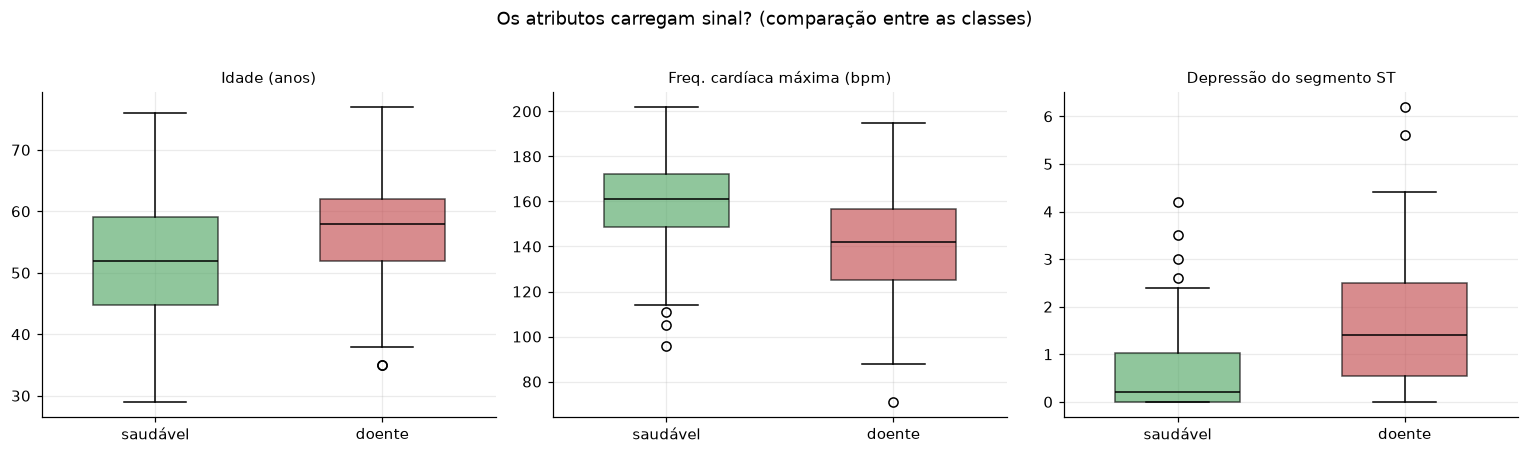

Proporção de doentes por tipo de dor no peito:
                  % saudável  % doente
dor_peito                             
angina_atipica          82.0      18.0
dor_nao_anginosa        79.1      20.9
angina_tipica           69.6      30.4
assintomatico           27.1      72.9


In [19]:
# Um pouco de análise exploratória: as variáveis clínicas separam as classes?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, titulo in zip(
    axes,
    ["idade", "freq_card_max", "depressao_st"],
    ["Idade (anos)", "Freq. cardíaca máxima (bpm)", "Depressão do segmento ST"],
):
    dados = [coracao.loc[coracao["doenca"] == c, col].dropna() for c in (0, 1)]
    bp = ax.boxplot(dados, patch_artist=True, widths=0.55)
    ax.set_xticks([1, 2], ["saudável", "doente"])
    for patch, cor in zip(bp["boxes"], [CORES[2], CORES[3]]):
        patch.set_facecolor(cor)
        patch.set_alpha(0.65)
    for mediana in bp["medians"]:
        mediana.set_color("black")
    ax.set_title(titulo, fontsize=10)

fig.suptitle("Os atributos carregam sinal? (comparação entre as classes)", y=1.02)
plt.tight_layout()
plt.show()

# Um atributo categórico
tabela = pd.crosstab(coracao["dor_peito"], coracao["doenca"], normalize="index")
tabela.columns = ["% saudável", "% doente"]
print("Proporção de doentes por tipo de dor no peito:")
print((tabela * 100).round(1).sort_values("% doente").to_string())

Observações clínicas que os dados confirmam: pacientes doentes tendem a ser **mais
velhos**, a atingir uma **frequência cardíaca máxima menor** no esforço e a apresentar
**maior depressão do segmento ST**. E a dor **assintomática** - contraintuitivamente -
é a mais associada à doença (justamente porque o paciente não sente o alerta).

Isso é ótimo sinal: se nenhum atributo separasse as classes, nenhum algoritmo faria
milagre. **Garbage in, garbage out.**

### 7.2 Pré-processamento

Antes de treinar, precisamos resolver dois problemas:

1. **Valores ausentes** - a maioria dos algoritmos não os aceita. Vamos **imputar**
   (preencher) com a mediana para numéricos e com a moda para categóricos.
2. **Atributos categóricos em texto** - `dor_peito` = `"assintomatico"` não é um
   número. Usaremos ***one-hot encoding***: uma coluna binária para cada categoria.

Faremos isso com um **`Pipeline`** do scikit-learn. Isso não é firula: o pipeline
garante que o pré-processamento seja **aprendido apenas no treino** e depois
**aplicado** ao teste. Se você calculasse a mediana usando o conjunto inteiro, estaria
vazando informação do teste para o treino - um erro clássico chamado ***data leakage***.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = coracao.drop(columns="doenca")
y = coracao["doenca"]

cols_categoricas = ["dor_peito", "talassemia"]
cols_numericas = [c for c in X.columns if c not in cols_categoricas]

preproc = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), cols_numericas),
    ("cat", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cols_categoricas),
])

print(f"Atributos numéricos   ({len(cols_numericas)}): {cols_numericas}")
print(f"Atributos categóricos ({len(cols_categoricas)}): {cols_categoricas}")

# Espiando o resultado do one-hot encoding
amostra = preproc.fit(X).transform(X.head(3))
nomes_saida = preproc.get_feature_names_out()
print(f"\nApós o pré-processamento: {len(cols_numericas) + len(cols_categoricas)} "
      f"colunas viraram {amostra.shape[1]}")
print("Novas colunas criadas pelo one-hot:")
print([n for n in nomes_saida if n.startswith("cat__")])

Atributos numéricos   (11): ['idade', 'sexo', 'pressao_repouso', 'colesterol', 'glicemia_alta', 'ecg_repouso', 'freq_card_max', 'angina_exercicio', 'depressao_st', 'inclinacao_st', 'n_vasos']
Atributos categóricos (2): ['dor_peito', 'talassemia']

Após o pré-processamento: 13 colunas viraram 18
Novas colunas criadas pelo one-hot:
['cat__dor_peito_angina_atipica', 'cat__dor_peito_angina_tipica', 'cat__dor_peito_assintomatico', 'cat__dor_peito_dor_nao_anginosa', 'cat__talassemia_defeito_fixo', 'cat__talassemia_defeito_reversivel', 'cat__talassemia_normal']


### 7.3 Holdout: separando treino e teste

> **Holdout**: o conjunto de dados é particionado aleatoriamente em dois. Tipicamente
> **2/3 para treinamento** e **1/3 para teste**.

Dois cuidados obrigatórios:

- `stratify=y` → mantém a **proporção das classes** nas duas partes (amostragem
  *estratificada*). Sem isso, o sorteio pode, por azar, concentrar doentes no teste.
- `random_state` → torna o sorteio **reprodutível**.

In [21]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=1 / 3, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {len(X_treino):3d} pacientes ({len(X_treino) / len(X):.0%})")
print(f"Teste : {len(X_teste):3d} pacientes ({len(X_teste) / len(X):.0%})")

print("\nProporção de doentes preservada pela estratificação:")
print(f"  base completa : {y.mean():.1%}")
print(f"  treino        : {y_treino.mean():.1%}")
print(f"  teste         : {y_teste.mean():.1%}")

# Conferindo, na prática, que os conjuntos são DISJUNTOS
intersecao = set(X_treino.index) & set(X_teste.index)
print(f"\nD_treino ∩ D_teste = {intersecao}  →  conjuntos disjuntos ✓")

Treino: 202 pacientes (67%)
Teste : 101 pacientes (33%)

Proporção de doentes preservada pela estratificação:
  base completa : 45.9%
  treino        : 46.0%
  teste         : 45.5%

D_treino ∩ D_teste = set()  →  conjuntos disjuntos ✓


### 7.4 A linha de base: o erro majoritário

Antes de comemorar qualquer resultado, precisamos de um **ponto de comparação**.

> Um classificador ingênuo que rotula **todos** os exemplos com a classe majoritária
> já acerta a proporção da classe majoritária. A taxa de erro desse "classificador"
> é o **erro majoritário**.
>
> **Um classificador só demonstra ter aprendido quando seu erro é menor que o erro
> majoritário.**

In [22]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent").fit(X_treino, y_treino)
acc_baseline = baseline.score(X_teste, y_teste)

print(f"Classe majoritária no treino : {'doente' if y_treino.mean() > 0.5 else 'saudável'}")
print(f"Acurácia do baseline no teste: {acc_baseline:.1%}")
print(f"ERRO MAJORITÁRIO             : {1 - acc_baseline:.1%}")
print(f"\n→ Qualquer modelo nosso precisa ficar ACIMA de {acc_baseline:.1%} "
      f"para provar que aprendeu algo.")

Classe majoritária no treino : saudável
Acurácia do baseline no teste: 54.5%
ERRO MAJORITÁRIO             : 45.5%

→ Qualquer modelo nosso precisa ficar ACIMA de 54.5% para provar que aprendeu algo.


🔎 **PARE E PENSE**: imagine uma base de detecção de fraude em que 99,8% das
transações são legítimas. Um modelo com **99,8% de acurácia** é excelente ou é
inútil? (Dica: qual é o erro majoritário?) Guarde essa pergunta para a Seção 8.

### 7.5 Treinando o classificador

In [23]:
modelo = Pipeline([
    ("preproc", preproc),
    ("arvore", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
])

modelo.fit(X_treino, y_treino)          # ← fase de APRENDIZADO (indução da hipótese h)
y_predito = modelo.predict(X_teste)     # ← fase de CLASSIFICAÇÃO (aplicação de h)

acc_modelo = accuracy_score(y_teste, y_predito)
print(f"Acurácia do baseline : {acc_baseline:.1%}")
print(f"Acurácia do modelo   : {acc_modelo:.1%}")
print(f"Ganho sobre o baseline: {acc_modelo - acc_baseline:+.1%}  →  o modelo APRENDEU ✓")

Acurácia do baseline : 54.5%
Acurácia do modelo   : 79.2%
Ganho sobre o baseline: +24.8%  →  o modelo APRENDEU ✓


In [24]:
# A hipótese aprendida, legível por um ser humano:
from sklearn.tree import export_text

nomes_atributos = [n.split("__", 1)[1] for n in modelo["preproc"].get_feature_names_out()]
print("REGRAS APRENDIDAS PELA ÁRVORE\n" + "=" * 60)
print(export_text(modelo["arvore"], feature_names=nomes_atributos,
                  class_names=["saudável", "doente"], decimals=1))

REGRAS APRENDIDAS PELA ÁRVORE
|--- talassemia_normal <= 0.5
|   |--- dor_peito_assintomatico <= 0.5
|   |   |--- freq_card_max <= 150.5
|   |   |   |--- class: doente
|   |   |--- freq_card_max >  150.5
|   |   |   |--- class: saudável
|   |--- dor_peito_assintomatico >  0.5
|   |   |--- depressao_st <= 0.5
|   |   |   |--- class: doente
|   |   |--- depressao_st >  0.5
|   |   |   |--- class: doente
|--- talassemia_normal >  0.5
|   |--- dor_peito_assintomatico <= 0.5
|   |   |--- n_vasos <= 2.5
|   |   |   |--- class: saudável
|   |   |--- n_vasos >  2.5
|   |   |   |--- class: doente
|   |--- dor_peito_assintomatico >  0.5
|   |   |--- n_vasos <= 0.5
|   |   |   |--- class: saudável
|   |   |--- n_vasos >  0.5
|   |   |   |--- class: doente



Pare um instante para apreciar isto: o algoritmo **descobriu sozinho**, a partir de
202 prontuários, que o resultado do exame de tálio, o tipo de dor no peito e o número
de vasos obstruídos são os indicadores mais informativos - e escreveu isso como um
conjunto de regras que um cardiologista pode ler, conferir e criticar. Essa é a força
dos modelos **simbólicos**.

🔎 **PARE E PENSE**: olhe com atenção e você encontrará um nó cujos **dois** filhos
levam à mesma classe. Por que o algoritmo se deu ao trabalho de fazer esse corte
inútil? (Dica: ele decide cada corte **localmente**, sem saber o que virá depois -
é uma busca *gulosa* no espaço de modelos. Voltaremos a isso na próxima aula.)

---
## 8. Avaliação: a matriz de confusão e suas métricas

Acurácia é só o começo. Para avaliar um classificador de verdade, partimos da
**matriz de confusão**: uma tabela $m \times m$ (para $m$ classes) em que a entrada
$MC_{ij}$ é o número de exemplos da classe $i$ que o classificador rotulou como $j$.

Para duas classes (positiva `+` e negativa `−`):

|  | **predito +** | **predito −** |
|---|---|---|
| **real +** | **TP** (verdadeiro positivo) | **FN** (falso negativo) |
| **real −** | **FP** (falso positivo) | **TN** (verdadeiro negativo) |

Idealmente, quase todos os exemplos ficam na **diagonal**.

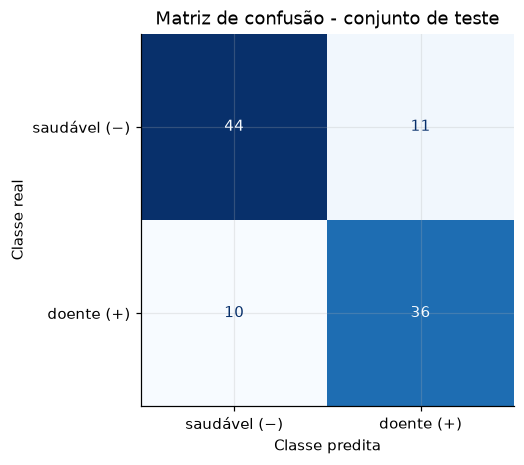

TP =  36  doentes  corretamente identificados como doentes
TN =  44  saudáveis corretamente identificados como saudáveis
FP =  11  saudáveis erroneamente classificados como DOENTES   (alarme falso)
FN =  10  doentes   erroneamente classificados como SAUDÁVEIS (doença não detectada)


In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

mc = confusion_matrix(y_teste, y_predito)
tn, fp, fn, tp = mc.ravel()

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ConfusionMatrixDisplay(mc, display_labels=["saudável (−)", "doente (+)"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")
ax.set_title("Matriz de confusão - conjunto de teste")
plt.show()

print(f"TP = {tp:3d}  doentes  corretamente identificados como doentes")
print(f"TN = {tn:3d}  saudáveis corretamente identificados como saudáveis")
print(f"FP = {fp:3d}  saudáveis erroneamente classificados como DOENTES   (alarme falso)")
print(f"FN = {fn:3d}  doentes   erroneamente classificados como SAUDÁVEIS (doença não detectada)")

### 8.1 As métricas, calculadas na mão

| Medida | Fórmula | O que responde |
|---|---|---|
| **Acurácia** | $\dfrac{TP + TN}{P + N}$ | de tudo, quanto acertei? |
| **Taxa de erro** | $\dfrac{FP + FN}{P + N}$ | de tudo, quanto errei? |
| **Revocação** (sensitividade, TVP) | $\dfrac{TP}{P}$ | dos que **são** positivos, quantos encontrei? |
| **Especificidade** (TVN) | $\dfrac{TN}{N}$ | dos que **são** negativos, quantos preservei? |
| **Precisão** | $\dfrac{TP}{TP + FP}$ | dos que **eu disse** positivos, quantos acertei? |
| **F1** | $\dfrac{2 \cdot precisão \cdot revocação}{precisão + revocação}$ | média harmônica das duas |

- **Revocação** é medida de **completude**: revocação = 1 significa que o classificador
  encontrou *todos* os positivos (mas não diz quantos negativos ele arrastou junto).
- **Precisão** é medida de **exatidão**: precisão = 1 significa que tudo que ele
  apontou como positivo realmente era (mas não diz quantos positivos ele deixou passar).

Vamos calcular tudo **na mão** e conferir com o scikit-learn.

In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score

P = tp + fn   # total de exemplos realmente positivos
N = tn + fp   # total de exemplos realmente negativos

acuracia       = (tp + tn) / (P + N)
taxa_erro      = (fp + fn) / (P + N)
revocacao      = tp / P
especificidade = tn / N
precisao       = tp / (tp + fp)
f1             = 2 * precisao * revocacao / (precisao + revocacao)

print(f"{'Medida':<32}{'na mão':>10}{'sklearn':>12}")
print("-" * 54)
print(f"{'Acurácia':<32}{acuracia:>10.4f}{accuracy_score(y_teste, y_predito):>12.4f}")
print(f"{'Taxa de erro':<32}{taxa_erro:>10.4f}{1 - accuracy_score(y_teste, y_predito):>12.4f}")
print(f"{'Revocação / Sensitividade':<32}{revocacao:>10.4f}{recall_score(y_teste, y_predito):>12.4f}")
print(f"{'Especificidade':<32}{especificidade:>10.4f}{recall_score(y_teste, y_predito, pos_label=0):>12.4f}")
print(f"{'Precisão':<32}{precisao:>10.4f}{precision_score(y_teste, y_predito):>12.4f}")
print(f"{'F1':<32}{f1:>10.4f}{f1_score(y_teste, y_predito):>12.4f}")

# Verificação automática: as contas à mão batem com a biblioteca?
assert np.isclose(acuracia, accuracy_score(y_teste, y_predito))
assert np.isclose(revocacao, recall_score(y_teste, y_predito))
assert np.isclose(precisao, precision_score(y_teste, y_predito))
assert np.isclose(f1, f1_score(y_teste, y_predito))
print("\n✓ Todas as fórmulas conferem com a implementação do scikit-learn.")

Medida                              na mão     sklearn
------------------------------------------------------
Acurácia                            0.7921      0.7921
Taxa de erro                        0.2079      0.2079
Revocação / Sensitividade           0.7826      0.7826
Especificidade                      0.8000      0.8000
Precisão                            0.7660      0.7660
F1                                  0.7742      0.7742

✓ Todas as fórmulas conferem com a implementação do scikit-learn.


### 8.2 Falso positivo × falso negativo: nem todo erro custa o mesmo

A acurácia trata os dois erros como equivalentes. Mas no nosso problema:

- **Falso positivo**: dizemos que um paciente saudável está doente. Consequência:
  susto, exames adicionais, custo.
- **Falso negativo**: dizemos que um paciente **doente** está saudável. Ele vai para
  casa sem tratamento. Consequência: possivelmente **fatal**.

Os dois erros são profundamente assimétricos. Num filtro de spam a assimetria se
inverte (um e-mail importante no lixo é pior que um spam na caixa de entrada). **É o
domínio do problema, e não a matemática, que decide qual métrica priorizar.**

Podemos deslocar esse equilíbrio ajustando o **limiar de decisão**: em vez de prever
"doente" quando $P(\text{doente}) > 0{,}5$, podemos baixar essa exigência.

In [27]:
probabilidades = modelo.predict_proba(X_teste)[:, 1]

# Uma árvore de profundidade 3 tem no máximo 8 folhas - logo, no máximo 8 valores
# distintos de probabilidade. Por isso limiares diferentes podem dar o MESMO resultado.
print("Probabilidades distintas produzidas por esta árvore:")
print("  " + "  ".join(f"{p:.2f}" for p in np.unique(probabilidades)) + "\n")

linhas = []
for limiar_dec in [0.85, 0.60, 0.40, 0.10]:
    pred = (probabilidades >= limiar_dec).astype(int)
    m = confusion_matrix(y_teste, pred)
    linhas.append({
        "limiar": limiar_dec,
        "FN (doentes perdidos)": m[1, 0],
        "FP (alarmes falsos)": m[0, 1],
        "revocação": recall_score(y_teste, pred, zero_division=0),
        "precisão": precision_score(y_teste, pred, zero_division=0),
        "acurácia": accuracy_score(y_teste, pred),
    })

print("Efeito do limiar de decisão sobre o tipo de erro cometido:\n")
print(pd.DataFrame(linhas).round(3).to_string(index=False))
print("\n→ Baixar o limiar encontra mais doentes (revocação ↑) ao custo de mais "
      "alarmes falsos (precisão ↓).\n  Não existe almoço grátis: existe uma ESCOLHA, "
      "e ela é clínica, não estatística.")

Probabilidades distintas produzidas por esta árvore:
  0.09  0.23  0.29  0.55  0.75  0.93  0.98  1.00

Efeito do limiar de decisão sobre o tipo de erro cometido:

 limiar  FN (doentes perdidos)  FP (alarmes falsos)  revocação  precisão  acurácia
   0.85                     23                    4      0.500     0.852     0.733
   0.60                     18                    8      0.609     0.778     0.743
   0.40                     10                   11      0.783     0.766     0.792
   0.10                      5                   24      0.891     0.631     0.713

→ Baixar o limiar encontra mais doentes (revocação ↑) ao custo de mais alarmes falsos (precisão ↓).
  Não existe almoço grátis: existe uma ESCOLHA, e ela é clínica, não estatística.


---
## 9. Escolhendo a complexidade sem trapacear

Lembra da curva em **U** da Seção 2? Vamos reencontrá-la, agora com a árvore de
decisão no problema real. O parâmetro que controla a complexidade é a **profundidade
máxima** da árvore.

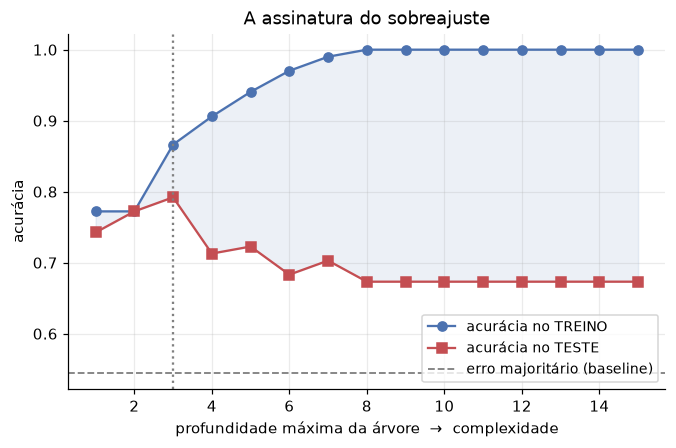

Melhor profundidade segundo o teste: 3
A área sombreada é a distância treino−teste: quanto maior, mais o modelo DECOROU
em vez de aprender.


In [28]:
profundidades = list(range(1, 16))
acc_treino, acc_teste = [], []

for prof in profundidades:
    m = Pipeline([
        ("preproc", preproc),
        ("arvore", DecisionTreeClassifier(max_depth=prof, random_state=RANDOM_STATE)),
    ]).fit(X_treino, y_treino)
    acc_treino.append(m.score(X_treino, y_treino))
    acc_teste.append(m.score(X_teste, y_teste))

melhor = profundidades[int(np.argmax(acc_teste))]

fig, ax = plt.subplots()
ax.plot(profundidades, acc_treino, "o-", color=CORES[0], label="acurácia no TREINO")
ax.plot(profundidades, acc_teste, "s-", color=CORES[3], label="acurácia no TESTE")
ax.axhline(acc_baseline, color="gray", ls="--", lw=1.2, label="erro majoritário (baseline)")
ax.axvline(melhor, color="gray", ls=":", lw=1.5)
ax.fill_between(profundidades, acc_teste, acc_treino, color=CORES[0], alpha=0.10)
ax.set_xlabel("profundidade máxima da árvore  →  complexidade")
ax.set_ylabel("acurácia")
ax.set_title("A assinatura do sobreajuste")
ax.legend(loc="lower right", fontsize=9)
plt.show()

print(f"Melhor profundidade segundo o teste: {melhor}")
print(f"A área sombreada é a distância treino−teste: quanto maior, mais o modelo "
      f"DECOROU\nem vez de aprender.")

A acurácia de treino sobe até 100% (a árvore consegue isolar cada paciente numa
folha). A de teste estaciona e depois cai. A área sombreada entre as curvas é a
assinatura visual do **overfitting**.

> ⚠️ **Atenção a uma armadilha sutil**: acabamos de escolher a profundidade
> *olhando para o conjunto de teste*. Isso é uma forma disfarçada de vazamento - o
> teste deixou de ser "dados nunca vistos". A solução correta é escolher
> hiperparâmetros por **validação cruzada** dentro do treino, e usar o teste **uma
> única vez**, no final. É o tema da próxima seção (e do Exercício 4).

---
## 10. Validação cruzada k-fold

O *holdout* tem um problema: o resultado depende de **um único sorteio**. Se der azar
na divisão, a estimativa fica enviesada. Vamos demonstrar isso.

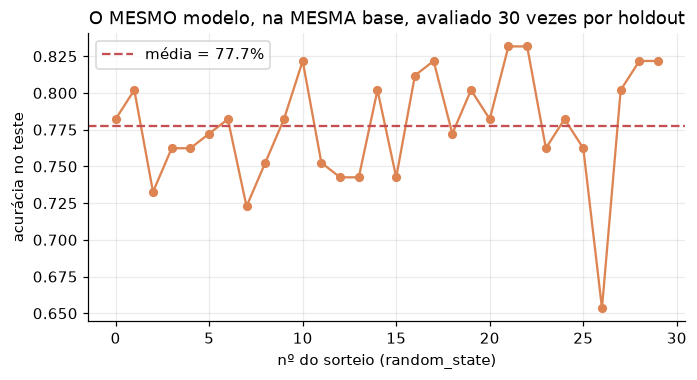

Menor acurácia obtida: 65.3%
Maior acurácia obtida: 83.2%
Amplitude            : 17.8%  ← só por causa do sorteio!


In [29]:
# Repetindo o holdout 30 vezes com sorteios diferentes
accs_holdout = []
for semente in range(30):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=1/3, random_state=semente, stratify=y)
    m = Pipeline([
        ("preproc", preproc),
        ("arvore", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
    ]).fit(Xa, ya)
    accs_holdout.append(m.score(Xb, yb))

accs_holdout = np.array(accs_holdout)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(30), accs_holdout, "o-", color=CORES[1], ms=5)
ax.axhline(accs_holdout.mean(), color=CORES[3], ls="--",
           label=f"média = {accs_holdout.mean():.1%}")
ax.set_xlabel("nº do sorteio (random_state)")
ax.set_ylabel("acurácia no teste")
ax.set_title("O MESMO modelo, na MESMA base, avaliado 30 vezes por holdout")
ax.legend()
plt.show()

print(f"Menor acurácia obtida: {accs_holdout.min():.1%}")
print(f"Maior acurácia obtida: {accs_holdout.max():.1%}")
print(f"Amplitude            : {accs_holdout.max() - accs_holdout.min():.1%}  ← só por causa do sorteio!")

Uma diferença de mais de 10 pontos percentuais **sem trocar nada no modelo**. Se você
reportar apenas um desses números no seu artigo, estará reportando sorte.

### A solução: k-fold cross validation

> Os dados são separados em $k$ subconjuntos independentes e de tamanhos iguais
> (*folds*). O procedimento de treino e teste é realizado $k$ vezes: a cada iteração
> $i$, o fold $D_i$ é usado para teste e os outros $k-1$ para treinamento. O
> resultado é a **média** dos $k$ resultados. Tipicamente $k = 10$.
>
> Na versão **estratificada**, os folds preservam a distribuição das classes.

**Todo exemplo é usado para teste exatamente uma vez.**

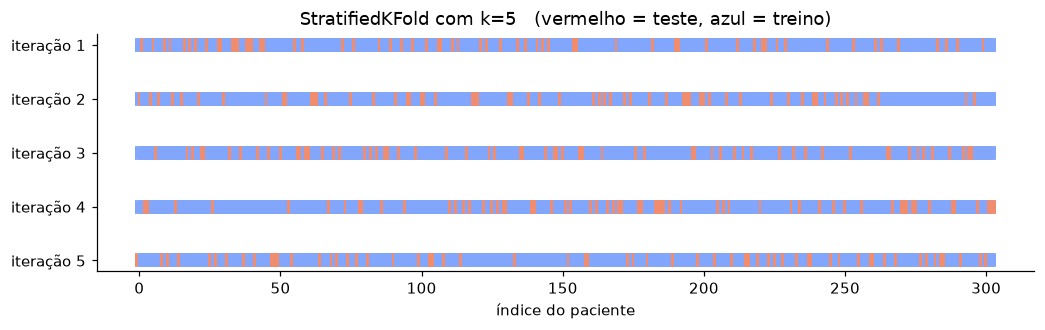

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Visualizando como os folds são montados
fig, ax = plt.subplots(figsize=(11, 2.8))
for i, (idx_treino, idx_teste) in enumerate(skf.split(X, y)):
    marcas = np.zeros(len(X))
    marcas[idx_teste] = 1
    ax.scatter(range(len(X)), [i] * len(X), c=marcas, marker="_", lw=9,
               cmap=plt.cm.coolwarm, vmin=-0.4, vmax=1.4)

ax.set_yticks(range(5))
ax.set_yticklabels([f"iteração {i + 1}" for i in range(5)])
ax.set_xlabel("índice do paciente")
ax.set_title("StratifiedKFold com k=5   (vermelho = teste, azul = treino)")
ax.grid(False)
ax.invert_yaxis()
plt.show()

In [31]:
modelo_cv = Pipeline([
    ("preproc", preproc),
    ("arvore", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
])

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(modelo_cv, X, y, cv=skf10, scoring="accuracy")

print("Acurácia em cada um dos 10 folds:")
print("  " + "  ".join(f"{s:.3f}" for s in scores))
print(f"\n10-Fold Cross Validation: {scores.mean():.1%} ± {scores.std():.1%}")
print(f"Holdout único (Seção 7)  : {acc_modelo:.1%}  (sem barra de erro!)")
print("\n→ Sempre reporte MÉDIA ± DESVIO PADRÃO. Um número sozinho esconde a incerteza.")

Acurácia em cada um dos 10 folds:
  0.903  0.871  0.839  0.833  0.767  0.700  0.800  0.667  0.867  0.700

10-Fold Cross Validation: 79.5% ± 7.8%
Holdout único (Seção 7)  : 79.2%  (sem barra de erro!)

→ Sempre reporte MÉDIA ± DESVIO PADRÃO. Um número sozinho esconde a incerteza.


### Matriz de confusão agregada

Assim como nos slides, a matriz final do processo de validação cruzada é obtida
**somando** as matrizes de cada fold. Como cada exemplo é testado exatamente uma vez,
isso equivale a montar uma única matriz com todas as predições fora-da-amostra.

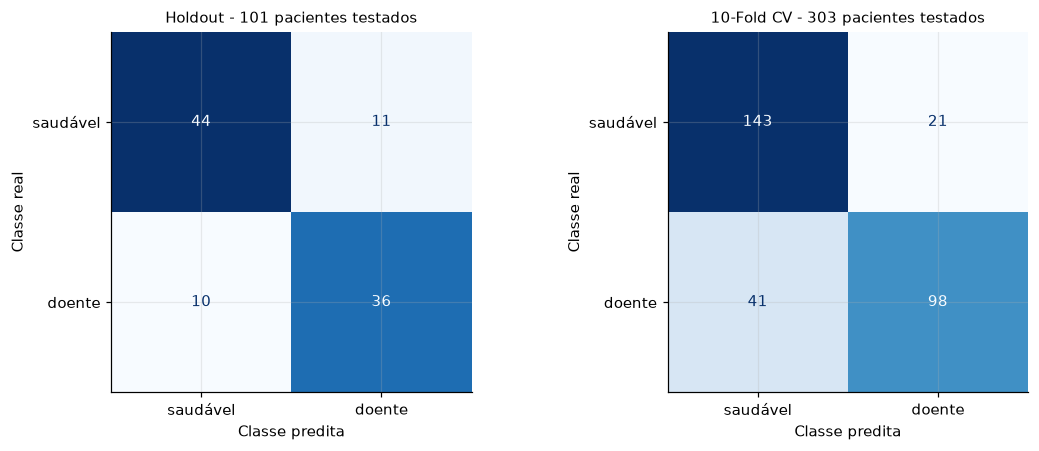

Relatório completo com validação cruzada:
              precision    recall  f1-score   support

    saudável      0.777     0.872     0.822       164
      doente      0.824     0.705     0.760       139

    accuracy                          0.795       303
   macro avg      0.800     0.788     0.791       303
weighted avg      0.798     0.795     0.793       303



In [32]:
y_pred_cv = cross_val_predict(modelo_cv, X, y, cv=skf10)
mc_cv = confusion_matrix(y, y_pred_cv)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, m, titulo in zip(
    axes, [mc, mc_cv],
    [f"Holdout - {len(y_teste)} pacientes testados",
     f"10-Fold CV - {len(y)} pacientes testados"],
):
    ConfusionMatrixDisplay(m, display_labels=["saudável", "doente"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Classe predita")
    ax.set_ylabel("Classe real")
plt.tight_layout()
plt.show()

print("Relatório completo com validação cruzada:")
from sklearn.metrics import classification_report
print(classification_report(y, y_pred_cv, target_names=["saudável", "doente"], digits=3))

### Holdout ou validação cruzada?

| | **Holdout** | **k-Fold Cross Validation** |
|---|---|---|
| Custo computacional | treina 1 vez | treina $k$ vezes |
| Viés da estimativa | maior | menor |
| Aproveitamento dos dados | usa 2/3 para treinar | usa $(k-1)/k$ e testa em 100% |
| Dá barra de erro? | não | sim |

**Regra prática**: prefira validação cruzada. Use holdout quando o custo de treinar
for proibitivo (redes neurais grandes) ou quando a base for tão pequena que dividi-la
em $k$ partes torne cada fold estatisticamente inútil.

---
## 11. Mais de duas classes: micro e macro averaging

Precisão e revocação foram definidas para **duas** classes. Com $m$ classes, a matriz
de confusão é $m \times m$ e há duas formas de resumir as métricas:

- **Microaveraging**: somam-se os componentes (TP, FP, FN) de todas as classes e só
  então aplica-se a fórmula. Cada **exemplo** pesa igual → favorece classes grandes.
  $$\text{Precisão}_{micro} = \frac{\sum_i TP_i}{\sum_i (TP_i + FP_i)}$$
- **Macroaveraging**: calcula-se a métrica de cada classe separadamente e tira-se a
  média. Cada **classe** pesa igual → dá voz às classes raras.
  $$\text{Precisão}_{macro} = \frac{\sum_i \text{Precisão}_i}{|C|}$$

Vamos voltar à Iris (3 classes), agora com uma base desbalanceada de propósito.

In [33]:
# Removendo exemplos para criar uma classe MINORITÁRIA e tornar a diferença visível
idx_manter = np.concatenate([
    np.where(y_num == 0)[0],
    np.where(y_num == 1)[0][:12],      # versicolor vira minoria
    np.where(y_num == 2)[0],
])
X_multi = X_iris.iloc[idx_manter]
y_multi = y_num[idx_manter]

print("Distribuição das classes (desbalanceada de propósito):")
for k, nome in enumerate(iris.target_names):
    print(f"  {nome:<12} {(y_multi == k).sum():3d}")

arvore_multi = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
y_pred_multi = cross_val_predict(
    arvore_multi, X_multi, y_multi,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
)

mc_multi = confusion_matrix(y_multi, y_pred_multi)
print("\nMatriz de confusão 3×3 (linhas = classe real, colunas = predita):")
print(pd.DataFrame(mc_multi, index=iris.target_names, columns=iris.target_names).to_string())

Distribuição das classes (desbalanceada de propósito):
  setosa        50
  versicolor    12
  virginica     50

Matriz de confusão 3×3 (linhas = classe real, colunas = predita):
            setosa  versicolor  virginica
setosa          50           0          0
versicolor       0          11          1
virginica        0           2         48


In [34]:
# Calculando micro e macro NA MÃO, a partir da matriz de confusão
TP_por_classe = np.diag(mc_multi)
FP_por_classe = mc_multi.sum(axis=0) - TP_por_classe   # coluna − diagonal
FN_por_classe = mc_multi.sum(axis=1) - TP_por_classe   # linha  − diagonal

precisao_por_classe  = TP_por_classe / (TP_por_classe + FP_por_classe)
revocacao_por_classe = TP_por_classe / (TP_por_classe + FN_por_classe)

print("Métricas por classe:")
print(pd.DataFrame({
    "TP": TP_por_classe, "FP": FP_por_classe, "FN": FN_por_classe,
    "precisão": precisao_por_classe.round(3), "revocação": revocacao_por_classe.round(3),
}, index=iris.target_names).to_string())

prec_micro = TP_por_classe.sum() / (TP_por_classe + FP_por_classe).sum()
prec_macro = precisao_por_classe.mean()
rev_micro  = TP_por_classe.sum() / (TP_por_classe + FN_por_classe).sum()
rev_macro  = revocacao_por_classe.mean()

print(f"\n{'':<12}{'na mão':>10}{'sklearn':>12}")
print("-" * 34)
print(f"{'micro prec.':<12}{prec_micro:>10.3f}"
      f"{precision_score(y_multi, y_pred_multi, average='micro'):>12.3f}")
print(f"{'macro prec.':<12}{prec_macro:>10.3f}"
      f"{precision_score(y_multi, y_pred_multi, average='macro'):>12.3f}")
print(f"{'micro rev. ':<12}{rev_micro:>10.3f}"
      f"{recall_score(y_multi, y_pred_multi, average='micro'):>12.3f}")
print(f"{'macro rev. ':<12}{rev_macro:>10.3f}"
      f"{recall_score(y_multi, y_pred_multi, average='macro'):>12.3f}")

print(f"\n→ A média MACRO é mais baixa porque a classe minoritária "
      f"('{iris.target_names[1]}', com poucos exemplos)\n  tem desempenho pior e, no "
      f"macro, ela pesa TANTO quanto as outras. O micro a dilui.")
print("\n→ Reporte MACRO quando as classes raras importam (fraude, doença rara, defeito).")

Métricas por classe:
            TP  FP  FN  precisão  revocação
setosa      50   0   0     1.000      1.000
versicolor  11   2   1     0.846      0.917
virginica   48   1   2     0.980      0.960

                na mão     sklearn
----------------------------------
micro prec.      0.973       0.973
macro prec.      0.942       0.942
micro rev.       0.973       0.973
macro rev.       0.959       0.959

→ A média MACRO é mais baixa porque a classe minoritária ('versicolor', com poucos exemplos)
  tem desempenho pior e, no macro, ela pesa TANTO quanto as outras. O micro a dilui.

→ Reporte MACRO quando as classes raras importam (fraude, doença rara, defeito).


---
## 12. Fechamento: o pipeline de um projeto de Aprendizado de Máquina

Percorremos, nesta aula, o ciclo completo. Guarde este checklist:

1. **Definir o problema** - quais são $T$, $P$ e $E$?
2. **Identificar a tarefa** - classificação, regressão, agrupamento, associação?
3. **Obter e entender os dados** - tipos de atributos, valores ausentes, distribuição
   das classes, representatividade da amostra
4. **Pré-processar** - imputação, codificação de categóricos, normalização
   (sempre **aprendendo no treino**, para não vazar informação)
5. **Separar treino e teste** - $D_{teste} \cap D_{treino} = \varnothing$, estratificado
6. **Estabelecer um baseline** - o erro majoritário
7. **Escolher o modelo e treinar** - induzir a hipótese $h$
8. **Selecionar hiperparâmetros por validação cruzada** - dentro do treino, nunca no teste
9. **Avaliar** - matriz de confusão e a métrica adequada ao domínio
10. **Interpretar e comunicar** - média ± desvio, e o que os erros significam no mundo real

### As três ideias que valem mais que qualquer algoritmo

1. **O erro de treino mente.** Só o desempenho em dados não vistos mede aprendizado.
2. **Acurácia sozinha engana.** Compare com o erro majoritário e escolha a métrica
   pelo custo real de cada tipo de erro.
3. **Um número sem incerteza não é um resultado.** Use validação cruzada e reporte a
   variabilidade.

> Na próxima aula vamos abrir a caixa-preta dos algoritmos: como uma árvore de decisão
> *escolhe* onde cortar, e como funcionam KNN, Naive Bayes e os demais modelos.

---
# 13. Exercícios

> 📌 **Leia antes de começar.**
> Nesta aula ainda **não estudamos nenhum algoritmo de classificação em detalhe** -
> isso começa na próxima. Por isso, **em todos os exercícios o código já vem pronto**:
> basta executar a célula e responder. O que se avalia aqui é o seu **raciocínio sobre
> metodologia e avaliação**, não a sua programação.
>
> Escreva as respostas nas células de texto indicadas (duplo clique para editar).
> O gabarito comentado está em `aula01-gabarito.ipynb` - **tente antes de olhar**.

---
### Exercício 1 - Matriz de confusão na mão *(o exercício dos slides)*

Considere a base de pacientes abaixo, com a classe real (`doente`) e a saída produzida
por um classificador (`saida`). A validação usou **3-fold cross validation**, com os
folds indicados na última coluna.

Este é o único exercício em que você escreve código - e ele **não envolve nenhum
classificador**: as predições já estão dadas. O que se pede é a **avaliação**.

**(a)** Execute a célula abaixo para montar a base.
**(b)** Complete a célula seguinte para calcular a matriz de confusão **de cada fold**.
**(c)** Obtenha a matriz final **somando** as três.
**(d)** Calcule acurácia, revocação e precisão a partir da matriz final.
**(e)** Compare com o erro majoritário. Esse classificador aprendeu alguma coisa?

In [35]:
# (a) - base já montada, apenas execute
pacientes = pd.DataFrame({
    "paciente": [f"P{i}" for i in range(1, 11)],
    "tosse":      ["SIM", "NÃO", "SIM", "SIM", "NÃO", "SIM", "NÃO", "NÃO", "NÃO", "SIM"],
    "febre":      ["NÃO", "NÃO", "NÃO", "SIM", "SIM", "NÃO", "NÃO", "SIM", "NÃO", "SIM"],
    "dor_cabeca": ["SIM", "SIM", "NÃO", "SIM", "SIM", "NÃO", "NÃO", "NÃO", "NÃO", "SIM"],
    "doente":     ["SIM", "NÃO", "NÃO", "SIM", "SIM", "SIM", "NÃO", "SIM", "NÃO", "SIM"],
    "saida":      ["NÃO", "SIM", "SIM", "NÃO", "SIM", "SIM", "SIM", "NÃO", "NÃO", "NÃO"],
    "fold":       [1, 2, 1, 2, 1, 3, 3, 2, 3, 3],
}).set_index("paciente")

# A classe POSITIVA (+) é "doente = SIM"
pacientes["real_bin"] = (pacientes["doente"] == "SIM").astype(int)
pacientes["pred_bin"] = (pacientes["saida"] == "SIM").astype(int)
pacientes

,tosse,febre,dor_cabeca,doente,saida,fold,real_bin,pred_bin
paciente,,,,,,,,
P1,SIM,NÃO,SIM,SIM,NÃO,1,1,0
P2,NÃO,NÃO,SIM,NÃO,SIM,2,0,1
P3,SIM,NÃO,NÃO,NÃO,SIM,1,0,1
P4,SIM,SIM,SIM,SIM,NÃO,2,1,0
P5,NÃO,SIM,SIM,SIM,SIM,1,1,1
P6,SIM,NÃO,NÃO,SIM,SIM,3,1,1
P7,NÃO,NÃO,NÃO,NÃO,SIM,3,0,1
P8,NÃO,SIM,NÃO,SIM,NÃO,2,1,0
P9,NÃO,NÃO,NÃO,NÃO,NÃO,3,0,0


In [36]:
# (b) e (c) - COMPLETE onde está indicado
#
# Dica: confusion_matrix(reais, preditos, labels=[0, 1]) devolve
#       [[TN, FP],
#        [FN, TP]]
# O argumento labels=[0, 1] é importante: sem ele, um fold que não contenha
# alguma das classes devolve uma matriz menor que 2×2 e a soma quebra.

matrizes = {}
for fold in sorted(pacientes["fold"].unique()):
    sub = pacientes[pacientes["fold"] == fold]

    mc_fold = ...          # <<< COMPLETE: matriz de confusão deste fold

    matrizes[fold] = mc_fold
    print(f"\n--- FOLD {fold} (pacientes: {', '.join(sub.index)}) ---")
    print(mc_fold)

mc_final = ...             # <<< COMPLETE: soma das matrizes dos folds
print("\nMATRIZ FINAL:\n", mc_final)


--- FOLD 1 (pacientes: P1, P3, P5) ---
Ellipsis

--- FOLD 2 (pacientes: P2, P4, P8) ---
Ellipsis

--- FOLD 3 (pacientes: P6, P7, P9, P10) ---
Ellipsis

MATRIZ FINAL:
 Ellipsis


In [37]:
# (d) e (e) - COMPLETE
# tn, fp, fn, tp = mc_final.ravel()
#
# acuracia  = ...
# revocacao = ...
# precisao  = ...
# erro_majoritario = ...

*Sua conclusão do Exercício 1 - o classificador aprendeu? (duplo clique para editar):*



---
### Exercício 2 - Formulando um problema

Escolha **um** dos problemas abaixo (ou proponha outro) e responda **em texto**:

- recomendar vídeos numa plataforma de streaming
- detectar fraude em transações de cartão de crédito
- prever a nota final de um aluno a partir do desempenho nas primeiras semanas
- agrupar clientes de uma loja por perfil de compra

**(a)** Qual é a tarefa $T$, a medida de desempenho $P$ e a experiência $E$?
**(b)** É classificação, regressão, agrupamento ou regras de associação?
**(c)** Qual paradigma: supervisionado, não supervisionado ou semissupervisionado?
Por quê?
**(d)** Nesse problema, qual erro é mais caro: falso positivo ou falso negativo?
Justifique - e diga qual métrica você reportaria.

*Sua resposta ao Exercício 2:*



---
### Exercício 3 - Três matrizes, três domínios

Abaixo estão as matrizes de confusão de três sistemas **reais e já treinados**. Você
não precisa saber qual algoritmo gerou cada uma - a avaliação independe disso.

Execute a célula e responda:

**(a)** Para cada cenário, calcule **acurácia, precisão, revocação e especificidade**
(a célula já faz as contas - apenas leia os resultados).
**(b)** Compare cada acurácia com o **erro majoritário** do respectivo cenário. Em qual
deles a acurácia é mais enganosa? Em algum caso a acurácia do sistema é **pior** que a
de um classificador que sempre responde a classe majoritária?
**(c)** Em cada cenário, qual erro é mais caro - falso positivo ou falso negativo? Qual
métrica você reportaria ao cliente?
**(d)** No cenário A, apenas cerca de 1 em cada 22 alarmes corresponde a um caso real.
Isso significa que o sistema é ruim e deve ser descartado? Justifique.

In [38]:
cenarios = {
    "A) Rastreamento de câncer por mamografia": dict(tp=45,  fn=5,  fp=950, tn=9000),
    "B) Filtro de spam de e-mail":              dict(tp=285, fn=15, fp=30,  tn=670),
    "C) Detecção de peça defeituosa":           dict(tp=60,  fn=40, fp=20,  tn=4880),
}

linhas = []
for nome, m in cenarios.items():
    tp_, fn_, fp_, tn_ = m["tp"], m["fn"], m["fp"], m["tn"]
    P_, N_ = tp_ + fn_, tn_ + fp_
    linhas.append({
        "cenário": nome,
        "positivos reais": P_,
        "negativos reais": N_,
        "acurácia": (tp_ + tn_) / (P_ + N_),
        "precisão": tp_ / (tp_ + fp_),
        "revocação": tp_ / P_,
        "especificidade": tn_ / N_,
        "erro majoritário": 1 - max(P_, N_) / (P_ + N_),
    })

print("A classe POSITIVA é sempre o evento raro que se quer detectar")
print("(tumor, spam, peça defeituosa).\n")
pd.DataFrame(linhas).set_index("cenário").round(4)

A classe POSITIVA é sempre o evento raro que se quer detectar
(tumor, spam, peça defeituosa).



,positivos reais,negativos reais,acurácia,precisão,revocação,especificidade,erro majoritário
cenário,,,,,,,
A) Rastreamento de câncer por mamografia,50,9950,0.9045,0.0452,0.90,0.9045,0.005
B) Filtro de spam de e-mail,300,700,0.9550,0.9048,0.95,0.9571,0.300
C) Detecção de peça defeituosa,100,4900,0.9880,0.7500,0.60,0.9959,0.020


*Sua resposta ao Exercício 3:*



---
### Exercício 4 - Por que validação cruzada?

A célula abaixo avalia **o mesmo modelo, na mesma base**, de duas formas: por holdout
repetido 30 vezes com sorteios diferentes, e por 10-fold cross validation.

Execute e responda:

**(a)** Qual foi a menor e a maior acurácia obtida por holdout? Qual a amplitude?
**(b)** Imagine dois colegas que fizeram o mesmo trabalho, cada um com um holdout
único, e reportaram números diferentes. Um deles fez algo errado?
**(c)** O que exatamente a validação cruzada resolve - e o que ela **não** resolve?
**(d)** Como você reportaria o resultado deste modelo num artigo, em uma linha?

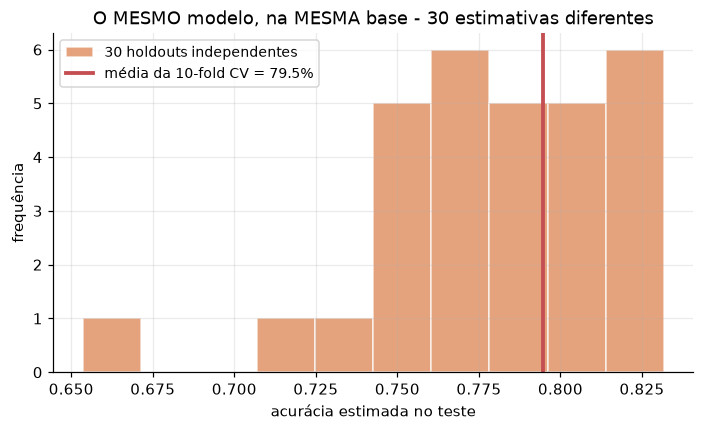

Holdout - menor : 65.3%
Holdout - maior : 83.2%
Holdout - amplitude: 17.8%

10-fold CV: 79.5% ± 7.8%


In [39]:
modelo_ex = Pipeline([
    ("preproc", preproc),
    ("arvore", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
])

# --- 30 holdouts independentes ---
accs_hold = []
for semente in range(30):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=1/3, random_state=semente, stratify=y)
    accs_hold.append(modelo_ex.fit(Xa, ya).score(Xb, yb))
accs_hold = np.array(accs_hold)

# --- 10-fold cross validation ---
scores_cv = cross_val_score(modelo_ex, X, y, cv=skf10, scoring="accuracy")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(accs_hold, bins=10, color=CORES[1], alpha=0.75, edgecolor="white",
        label="30 holdouts independentes")
ax.axvline(scores_cv.mean(), color=CORES[3], lw=2.5,
           label=f"média da 10-fold CV = {scores_cv.mean():.1%}")
ax.set_xlabel("acurácia estimada no teste")
ax.set_ylabel("frequência")
ax.set_title("O MESMO modelo, na MESMA base - 30 estimativas diferentes")
ax.legend(fontsize=9)
plt.show()

print(f"Holdout - menor : {accs_hold.min():.1%}")
print(f"Holdout - maior : {accs_hold.max():.1%}")
print(f"Holdout - amplitude: {accs_hold.max() - accs_hold.min():.1%}")
print(f"\n10-fold CV: {scores_cv.mean():.1%} ± {scores_cv.std():.1%}")

*Sua resposta ao Exercício 4:*



---
### Exercício 5 - Diagnosticando o sobreajuste

A célula abaixo varia a complexidade de um modelo (a profundidade da árvore) e mede o
desempenho no treino e no teste - a mesma curva da Seção 9, agora para você
interpretar.

**(a)** Identifique no gráfico as três regiões: **sub-ajuste** (*underfitting*),
**ponto de melhor generalização** e **sobreajuste** (*overfitting*). Em torno de qual
profundidade cada uma começa?
**(b)** A acurácia de treino chega a 100%. Por que isso, sozinho, não é motivo para
comemorar? O que a árvore está fazendo com os pacientes atípicos?
**(c)** A segunda célula compara duas maneiras de escolher a profundidade: por
validação cruzada **dentro do treino** (honesta) e olhando diretamente o **teste**
(trapaça). O experimento é repetido em 25 divisões diferentes. Qual das duas produz,
em média, um número maior? Por que isso acontece, se o modelo é exatamente o mesmo?
**(d)** Explique, em suas palavras, por que reportar o resultado da trapaça seria
desonesto mesmo sem intenção de enganar ninguém.

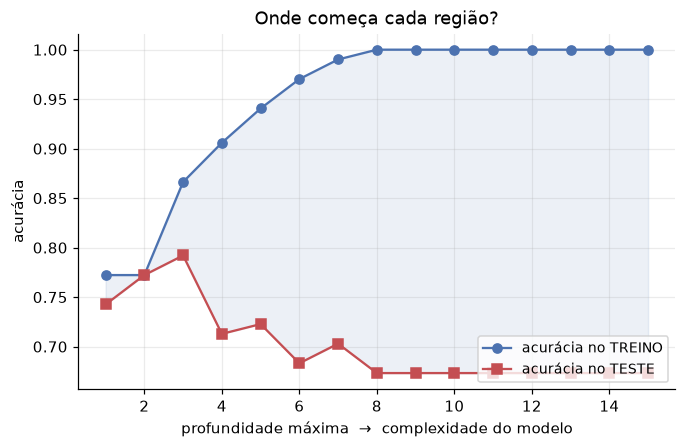

In [40]:
profs = list(range(1, 16))
acc_tr, acc_te = [], []
for prof in profs:
    m = Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(max_depth=prof,
                                                    random_state=RANDOM_STATE))]).fit(X_treino, y_treino)
    acc_tr.append(m.score(X_treino, y_treino))
    acc_te.append(m.score(X_teste, y_teste))

fig, ax = plt.subplots()
ax.plot(profs, acc_tr, "o-", color=CORES[0], label="acurácia no TREINO")
ax.plot(profs, acc_te, "s-", color=CORES[3], label="acurácia no TESTE")
ax.fill_between(profs, acc_te, acc_tr, color=CORES[0], alpha=0.10)
ax.set_xlabel("profundidade máxima  →  complexidade do modelo")
ax.set_ylabel("acurácia")
ax.set_title("Onde começa cada região?")
ax.legend(loc="lower right", fontsize=9)
plt.show()

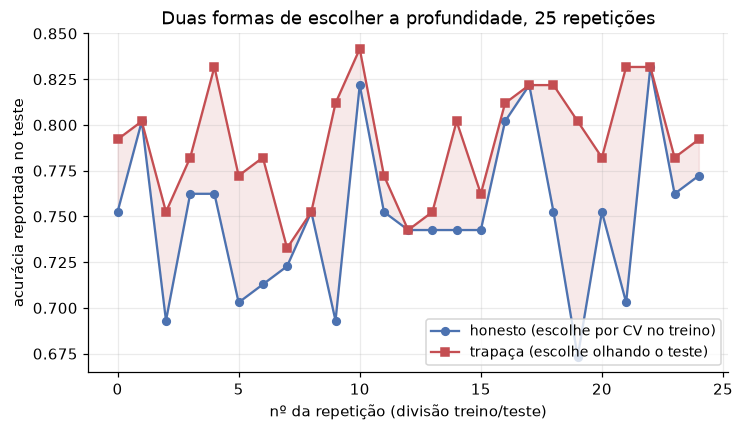

Média honesta   : 75.1%
Média trapaceada: 79.0%
Diferença média : +4.0%


In [41]:
from sklearn.model_selection import GridSearchCV

honestas, trapaceadas = [], []
for semente in range(25):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=1/3, random_state=semente, stratify=y)

    # Honesto: escolhe a profundidade por validação cruzada DENTRO do treino
    g = GridSearchCV(
        Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
        param_grid={"arvore__max_depth": profs},
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    honestas.append(g.score(Xb, yb))

    # Trapaça: testa as 15 profundidades no TESTE e reporta a melhor
    trapaceadas.append(max(
        Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(max_depth=p,
                                                    random_state=RANDOM_STATE))]).fit(Xa, ya).score(Xb, yb)
        for p in profs
    ))

honestas, trapaceadas = np.array(honestas), np.array(trapaceadas)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(honestas, "o-", color=CORES[0], ms=5, label="honesto (escolhe por CV no treino)")
ax.plot(trapaceadas, "s-", color=CORES[3], ms=5, label="trapaça (escolhe olhando o teste)")
ax.fill_between(range(25), honestas, trapaceadas, color=CORES[3], alpha=0.12)
ax.set_xlabel("nº da repetição (divisão treino/teste)")
ax.set_ylabel("acurácia reportada no teste")
ax.set_title("Duas formas de escolher a profundidade, 25 repetições")
ax.legend(fontsize=9)
plt.show()

print(f"Média honesta   : {honestas.mean():.1%}")
print(f"Média trapaceada: {trapaceadas.mean():.1%}")
print(f"Diferença média : {(trapaceadas - honestas).mean():+.1%}")

*Sua resposta ao Exercício 5:*



---
### Exercício 6 - A decisão clínica

Um hospital estabelece que o sistema de triagem **não pode deixar passar mais de 10%
dos pacientes doentes** - ou seja, exige **revocação ≥ 0,90**.

A célula abaixo mostra todos os pontos de operação que o modelo consegue oferecer,
obtidos variando o **limiar de decisão** (em vez de prever "doente" quando
$P(\text{doente}) > 0{,}5$, exigimos mais ou menos evidência).

**(a)** Qual é o **maior** limiar que ainda atende à exigência do hospital? Por que
queremos o maior, e não o menor?
**(b)** Comparado ao limiar padrão de 0,50, quantos doentes a mais são encontrados?
E quantos alarmes falsos a mais isso custa?
**(c)** A acurácia **piora** ao adotar a política clínica. Isso significa que a decisão
está errada? Explique.
**(d)** Em uma frase: quem deveria escolher o ponto de operação - o cientista de dados
ou o corpo clínico? Por quê?

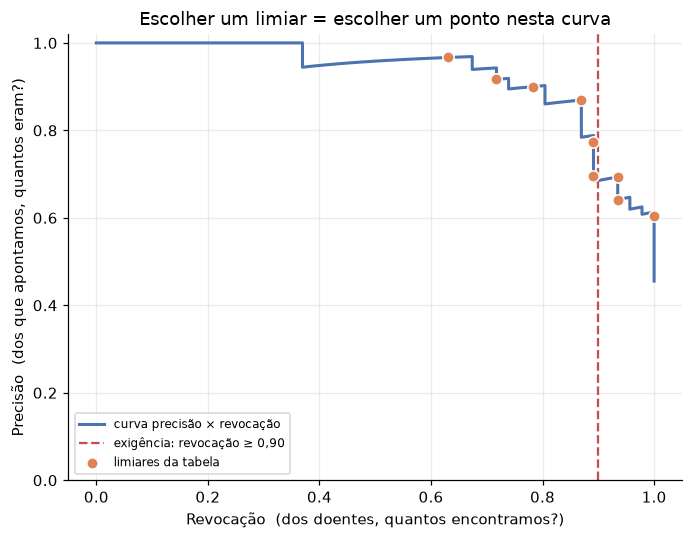

,limiar,doentes encontrados (TP),doentes perdidos (FN),alarmes falsos (FP),revocação,precisão,acurácia
0,0.10,46,0,30,1.000,0.605,0.703
1,0.20,43,3,24,0.935,0.642,0.733
2,0.25,43,3,19,0.935,0.694,0.782
3,0.30,41,5,18,0.891,0.695,0.772
4,0.40,41,5,12,0.891,0.774,0.832
5,0.50,40,6,6,0.870,0.870,0.881
6,0.60,36,10,4,0.783,0.900,0.861
7,0.70,33,13,3,0.717,0.917,0.842
8,0.80,29,17,1,0.630,0.967,0.822


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import StandardScaler

modelo_prob = Pipeline([
    ("preproc", preproc),
    ("escala", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=1000)),
]).fit(X_treino, y_treino)

probs = modelo_prob.predict_proba(X_teste)[:, 1]

# Tabela de pontos de operação
pontos = []
for t in [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred = (probs >= t).astype(int)
    m = confusion_matrix(y_teste, pred, labels=[0, 1])
    pontos.append({
        "limiar": t,
        "doentes encontrados (TP)": m[1, 1],
        "doentes perdidos (FN)": m[1, 0],
        "alarmes falsos (FP)": m[0, 1],
        "revocação": recall_score(y_teste, pred, zero_division=0),
        "precisão": precision_score(y_teste, pred, zero_division=0),
        "acurácia": accuracy_score(y_teste, pred),
    })
tabela_pontos = pd.DataFrame(pontos)

prec_c, rev_c, _ = precision_recall_curve(y_teste, probs)
fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot(rev_c, prec_c, "-", color=CORES[0], lw=2, label="curva precisão × revocação")
ax.axvline(0.90, color=CORES[3], ls="--", lw=1.5, label="exigência: revocação ≥ 0,90")
ax.scatter(tabela_pontos["revocação"], tabela_pontos["precisão"], s=55,
           color=CORES[1], zorder=5, edgecolor="white", label="limiares da tabela")
ax.set_xlabel("Revocação  (dos doentes, quantos encontramos?)")
ax.set_ylabel("Precisão  (dos que apontamos, quantos eram?)")
ax.set_title("Escolher um limiar = escolher um ponto nesta curva")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

tabela_pontos.round(3)

*Sua resposta ao Exercício 6:*



---
### Exercício 7 - Quando a classe é contínua (regressão)

Até aqui só fizemos classificação. A célula abaixo troca a tarefa: em vez de prever se
o paciente está doente, prevê a sua **frequência cardíaca máxima** - um valor contínuo.

**(a)** Por que **não** usamos acurácia para avaliar este modelo? O que significaria
"acertar" 152,3 bpm quando o valor real é 152,0?
**(b)** Interprete o **MAE** do melhor modelo em linguagem clínica: em média, o modelo
erra por quantos batimentos por minuto?
**(c)** O $R^2$ do baseline é exatamente 0, e o da árvore sem limite de profundidade é
**negativo**. O que cada um desses valores significa? Como um modelo consegue ser
*pior que prever sempre a média*?
**(d)** No gráfico de valor real × predito, que figura um modelo perfeito produziria?
Por que a árvore de profundidade 3 forma "faixas horizontais"?

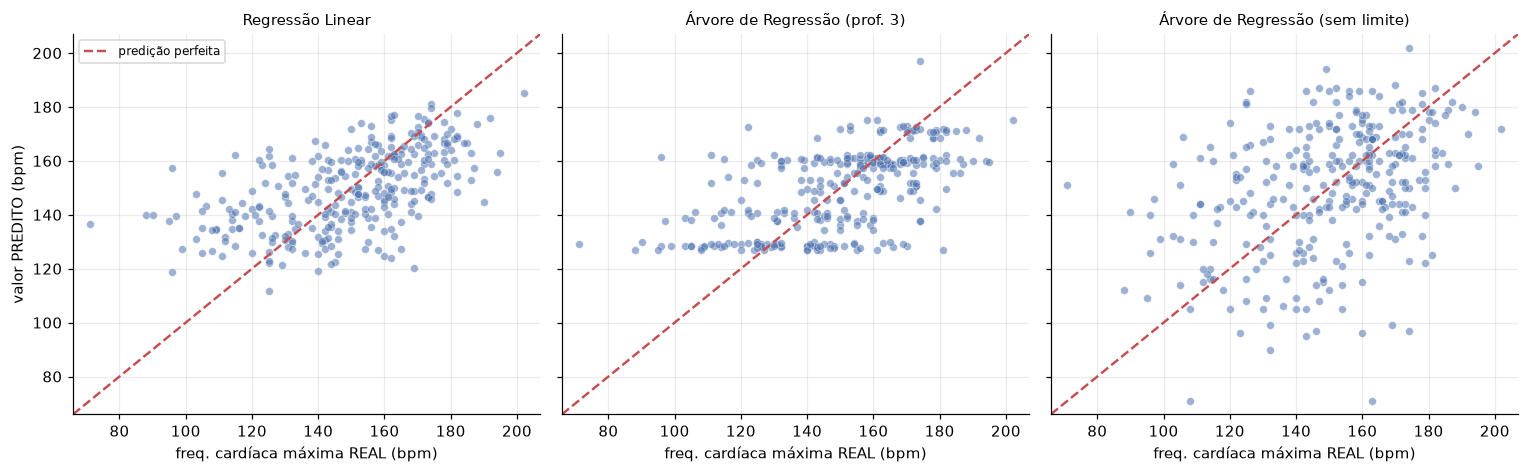

,modelo,MAE (bpm),RMSE (bpm),R²
0,Baseline (prever sempre a média),18.450,22.837,0.000
1,Regressão Linear,14.863,18.921,0.314
2,Árvore de Regressão (prof. 3),14.498,18.761,0.325
3,Árvore de Regressão (sem limite),20.657,26.080,-0.304


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.tree import DecisionTreeRegressor

X_reg = coracao.drop(columns=["freq_card_max"])   # o alvo SAI dos atributos!
y_reg = coracao["freq_card_max"]

cols_cat_r = ["dor_peito", "talassemia"]
cols_num_r = [c for c in X_reg.columns if c not in cols_cat_r]
preproc_reg = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), cols_num_r),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cols_cat_r),
])

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
regressores = {
    "Baseline (prever sempre a média)": None,
    "Regressão Linear": LinearRegression(),
    "Árvore de Regressão (prof. 3)": DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    "Árvore de Regressão (sem limite)": DecisionTreeRegressor(random_state=RANDOM_STATE),
}

res_reg, preds_reg = [], {}
for nome, est in regressores.items():
    pred = (np.full(len(y_reg), y_reg.mean()) if est is None
            else cross_val_predict(Pipeline([("preproc", preproc_reg), ("reg", est)]),
                                   X_reg, y_reg, cv=kf))
    preds_reg[nome] = pred
    erro = y_reg - pred
    res_reg.append({
        "modelo": nome,
        "MAE (bpm)": np.abs(erro).mean(),
        "RMSE (bpm)": np.sqrt((erro ** 2).mean()),
        "R²": 1 - (erro ** 2).sum() / ((y_reg - y_reg.mean()) ** 2).sum(),
    })

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True)
for ax, nome in zip(axes, ["Regressão Linear", "Árvore de Regressão (prof. 3)",
                           "Árvore de Regressão (sem limite)"]):
    ax.scatter(y_reg, preds_reg[nome], s=26, alpha=0.55, color=CORES[0],
               edgecolor="white", linewidth=0.4)
    lims = [y_reg.min() - 5, y_reg.max() + 5]
    ax.plot(lims, lims, ls="--", color=CORES[3], lw=1.6, label="predição perfeita")
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel("freq. cardíaca máxima REAL (bpm)")
    ax.set_xlim(lims); ax.set_ylim(lims)
axes[0].set_ylabel("valor PREDITO (bpm)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(res_reg).round(3)

*Sua resposta ao Exercício 7:*



---
### Exercício 8 - Desafio: e sem rótulo nenhum?

A célula abaixo **esconde completamente** a coluna `doenca` e agrupa os pacientes
usando apenas a geometria dos atributos (aprendizado **não supervisionado**).

**(a)** Olhando a tabela cruzada, o algoritmo "redescobriu" a doença sem nunca ter
visto um diagnóstico?
**(b)** Descreva o perfil clínico médio de cada grupo. Eles fazem sentido do ponto de
vista médico?
**(c)** Por que **não** faz sentido calcular acurácia entre grupo e classe real?
*(Dica: o que aconteceria se o algoritmo tivesse numerado os grupos ao contrário?)*
**(d)** Num problema **genuinamente** não supervisionado não existiria a coluna
`doenca` para conferir. Como você avaliaria a qualidade do agrupamento nesse caso?

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

X_sem_rotulo = coracao.drop(columns="doenca")     # a classe NUNCA é vista pelo algoritmo

grupos_ex = Pipeline([
    ("preproc", preproc),
    ("escala", StandardScaler(with_mean=False)),
    ("kmeans", KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)),
]).fit(X_sem_rotulo)["kmeans"].labels_

tab = pd.crosstab(grupos_ex, coracao["doenca"],
                  rownames=["grupo descoberto"], colnames=["classe real"])
tab.columns = ["saudável (0)", "doente (1)"]
print(tab.to_string())
print(f"\nÍndice de Rand Ajustado: {adjusted_rand_score(coracao['doenca'], grupos_ex):.3f}"
      f"   (0 = acaso, 1 = partições idênticas)\n")

perfil = coracao.assign(grupo=grupos_ex).groupby("grupo")[
    ["idade", "freq_card_max", "n_vasos", "depressao_st", "sexo", "doenca"]].mean()
perfil.columns = ["idade média", "freq. card. máx.", "nº vasos", "depressão ST",
                  "prop. masculino", "prop. doentes"]
perfil.round(2)

                  saudável (0)  doente (1)
grupo descoberto                          
0                           24         113
1                          140          26

Índice de Rand Ajustado: 0.447   (0 = acaso, 1 = partições idênticas)



,idade média,freq. card. máx.,nº vasos,depressão ST,prop. masculino,prop. doentes
grupo,,,,,,
0,57.01,137.40,1.12,1.67,0.85,0.82
1,52.31,159.68,0.30,0.52,0.54,0.16


*Sua resposta ao Exercício 8:*



---
## Referências

- MITCHELL, T. *Machine Learning*. McGraw-Hill, 1997. (capítulo 1)
- RUSSELL, S.; NORVIG, P. *Artificial Intelligence: A Modern Approach*. 3. ed.
  Prentice Hall, 2009. (capítulo 18)
- BISHOP, C. *Pattern Recognition and Machine Learning*. Springer, 2006. (capítulo 1)
- JAMES, G. et al. *An Introduction to Statistical Learning*. Springer, 2013.
- DETRANO, R. et al. International application of a new probability algorithm for the
  diagnosis of coronary artery disease. *American Journal of Cardiology*, 64:304-310, 1989.
- Documentação do scikit-learn: <https://scikit-learn.org/stable/user_guide.html>